<a href="https://colab.research.google.com/github/ch-manasa/AI-and-ML/blob/main/AirlinesQAFlykite.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Flykite Airlines - HR Policy Q&A Bot

## Executive Summary
This notebook builds and evaluates an HR policy question-answering system for Flykite Airlines using three progressively more capable approaches: (1) a base LLM with no company-specific knowledge, (2) the same LLM with engineered prompts, and (3) a Retrieval-Augmented Generation (RAG) system grounded in the actual employee handbook, tuned across seven hyperparameter configurations plus one follow-up chunking experiment. The objective is to determine which approach reliably answers real employee questions with accurate, source-grounded information, and to recommend the configuration Flykite should take forward for further validation.

**Report sections:** Problem Statement → Data Overview → Evaluation Question Set → Question Answering using LLM → Prompt Engineering → RAG Data Preparation → Question Answering using RAG → RAG Fine-Tuning → Actionable Insights and Recommendations → Conclusion.

# Problem Statement

## Business Context
Modern organizations operate in an environment where internal policies have grown increasingly complex, covering leaves, reimbursements, travel, hybrid work norms, performance management, compliance, and more. These policies are commonly documented in static, lengthy HR handbooks or PDFs, which employees often find difficult to search or apply. HR teams are burdened with repetitive queries, employees experience delays and confusion, and both sides lose productivity.

## Objective
Develop a prototype demonstrating how NLP powered by Retrieval-Augmented Generation (RAG) can help employees query Flykite Airlines HR policies and receive accurate, context-aware, understandable answers that:

* Retrieve relevant content from the
official HR handbook
* Handle ambiguous, sensitive, real-world employee scenarios
* Cite sources (section/clause) to build trust and compliance


## Evaluation Questions
1. What are the effects on the benefits I receive if my probation is extended?
2. There has been a demise in my family last night, and I need to attend the last rites. How should I inform the office, and will I be granted leave?
3. What should I do if I notice suspected harassment with my female colleague?


## Data Description
The Flykite Airlines HR Policy Handbook — a single PDF covering Employment Policies, Equal Opportunity & Anti-Harassment, Special Leave, Leave Accrual, Expense Reimbursement, Data Protection, Attendance, Payroll, Performance Extensions, Compensation, Workplace Safety, Training, Code of Conduct, and Grievance Procedures.

**Important — before running:** Runtime -> Change runtime type -> Hardware accelerator -> GPU (T4).

**Sources and external resources used**
* LLM: Qwen/Qwen2.5-7B-Instruct from Hugging Face (open-source, loaded in 4-bit with bitsandbytes)
* Embedding model: all-MiniLM-L6-v2 (sentence-transformers, Hugging Face)
* Vector database: ChromaDB, used through LangChain
* Data: Flykite Airlines HR Policy Handbook (PDF provided with the project)

# 1. Installing and Importing the Necessary Libraries


In [12]:
#Installing the libraries with specified versions (all free/open-source, no paid APIs)
!pip install -q -U \
    langchain==0.3.9 langchain-community==0.3.9 langchain-huggingface==0.1.2 \
    langchain-text-splitters==0.3.2 chromadb==0.5.20 pypdf==5.1.0 \
    sentence-transformers==3.3.1 bitsandbytes -q

print("Install complete.")

Install complete.


**Note:** After running the above cell, restart the runtime (Runtime -> Restart session) and run all cells sequentially from the next cell. This avoids dependency conflicts between transformers/accelerate and pre-installed Colab packages.



In [1]:
import warnings
warnings.filterwarnings("ignore")

import os
import json
import time
import textwrap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch

from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig, set_seed
set_seed(42)
print("Logging configured and random seed set to 42.")
from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_community.vectorstores import Chroma

pd.set_option("display.max_colwidth", None)
sns.set_style("whitegrid")

print("GPU available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("Device name:", torch.cuda.get_device_name(0))

Logging configured and random seed set to 42.
GPU available: True
Device name: Tesla T4


In [2]:
import logging

os.environ["ANONYMIZED_TELEMETRY"] = "False"
logging.getLogger("chromadb.telemetry.product.posthog").setLevel(logging.CRITICAL)

print("Logging configured")

Logging configured


**Observation:** The runtime reports a Tesla T4 GPU (GPU available: True). The 7B model loaded in Section 5 needs this GPU; on CPU it would not load in a reasonable time.

# 2. Loading the Dataset


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
pdf_path = "/content/drive/MyDrive/AI&ML/Capstone/Dataset - Flykite Airlines_ HRP.pdf"
print("Loaded file:", pdf_path)

Loaded file: /content/drive/MyDrive/AI&ML/Capstone/Dataset - Flykite Airlines_ HRP.pdf


In [5]:
loader = PyPDFLoader(pdf_path)
raw_docs = loader.load()

print("Number of pages loaded:", len(raw_docs))
print("Total characters across all pages:", sum(len(d.page_content) for d in raw_docs))
print("\n--- Sample content (page 1, first 500 chars) ---\n")
print(raw_docs[0].page_content[:500])

Number of pages loaded: 14
Total characters across all pages: 18186

--- Sample content (page 1, first 500 chars) ---

 
Flykite  Airlines:  Human  Resources  Policy  
Handbook
 
Introduction  Flykite  Airlines  is  dedicated  to  cultivating  an  organizational  culture  that  synergizes  
operational
 
excellence
 
with
 
a
 
supportive,
 
equitable,
 
and
 
legally
 
compliant
 
workplace
 
environment
 
across
 
all
 
departments
 
and
 
employee
 
levels.
 
This
 
document
 
establishes
 
an
 
exhaustive
 
framework
 
comprising
 
all
 
human
 
resource
 
policies
 
currently
 
in
 
effect.
 
All
 
provisio


**Observation:**

* The handbook has 14 pages and 18,186 characters before cleaning (12,879 after cleaning, roughly 2,000 words).
* It is a short, single-topic document, so a small number of chunks and a small k are enough to cover it. This shaped the chunk-size test in Section 7.1 and the tuning grid in Section 9.
* The sample page shows a recurring watermark/disclaimer and irregular spacing from PDF extraction. Both are cleaned in Section 3.1.

# 3. Data Overview

In [6]:
# Per-page character counts -- gives a sense of density/structure across the handbook
page_lengths = [len(d.page_content) for d in raw_docs]
overview_df = pd.DataFrame({
    "page_number": [d.metadata.get("page", i) + 1 for i, d in enumerate(raw_docs)],
    "char_count": page_lengths
})
overview_df

,page_number,char_count
0,1,1656
1,2,1570
2,3,1490
3,4,1558
4,5,1528
5,6,1213
6,7,1460
7,8,1447
8,9,1276
9,10,1097


**Observation:**

* Page density is uneven across the 14-page handbook. The average is about 1,300 characters per page.
* The three densest pages are Page 1 (1,656), Page 2 (1,570) and Page 4 (1,558). The sparsest are Page 14 (413) and Page 11 (1,041).
* Pages 1 and 2 hold the Probationary Employment Policy, so the clause needed for Q1 sits in the two most tightly packed pages. Chunks must be large enough to keep a full clause together. Section 7.1 tests this directly.
* These counts are measured before cleaning, so they include the per-page watermark removed in Section 3.1.

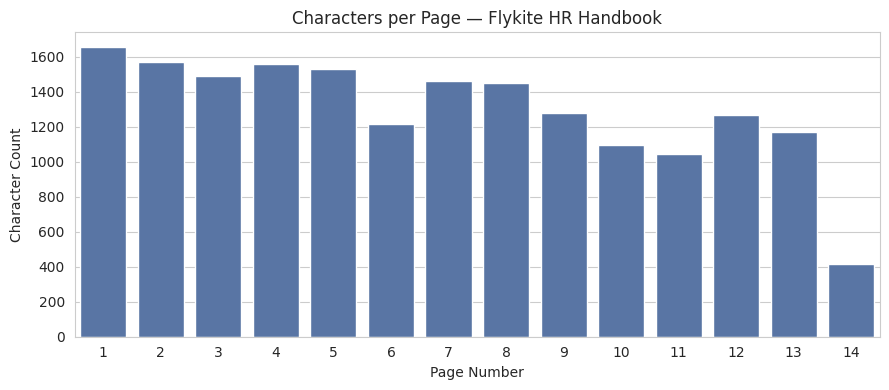

In [7]:
plt.figure(figsize=(9,4))
sns.barplot(data=overview_df, x="page_number", y="char_count", color="#4C72B0")
plt.title("Characters per Page — Flykite HR Handbook")
plt.xlabel("Page Number")
plt.ylabel("Character Count")
plt.tight_layout()
plt.show()

**Observation:**

* Page length falls through the document. Pages 1 to 5 (Probation and Anti-Discrimination) are all above 1,450 characters, while pages 9 to 11 (Attendance, Payroll, Performance Extensions) sit between about 1,000 and 1,300.
* Page 14 (413 characters) is an outlier because it only closes the Grievance and Disciplinary section.
* The earlier policies carry more sub-clause detail per page. The Q1 answer sits in this dense section (pages 1 to 2), which is why chunk size is tested in Sections 7.1 and 9.

## 3.1 Data Preprocessing — Cleaning Extraction Artifacts

Two data-quality issues were identified while inspecting the raw pages during Data Overview above:

1. A recurring per-page watermark/disclaimer (a personal-use notice with an embedded email address and tracking code) concatenated directly into the policy text.
2. Irregular multi-space artifacts between words and before punctuation, introduced by PDF text extraction.

Both are corrected below, before the document is split into chunks, so every downstream section (Evaluation Question Set, LLM Q&A, RAG chunking) works from clean text.

In [8]:
# Two data-quality issues found during Data Overview, fixed here before any further processing:
# (1) a recurring per-page watermark/disclaimer, (2) irregular multi-space extraction artifacts.
import re

print("Before cleaning:")
print("Total characters across all pages:", sum(len(d.page_content) for d in raw_docs))

watermark_pattern = re.compile(
    r"[\w\.-]+@[\w\.-]+\.\w+\s*"                                    # embedded email
    r"[A-Z0-9]{8,}\s*"                                                   # tracking code
    r"This file is meant for personal use by.*?legal action\.?",         # disclaimer sentence
    flags=re.IGNORECASE | re.DOTALL,
)

for doc in raw_docs:
    doc.page_content = watermark_pattern.sub("", doc.page_content)
    doc.page_content = re.sub(r"\s+", " ", doc.page_content).strip()          # collapse multi-space
    doc.page_content = re.sub(r"\s+([,.;:])", r"\1", doc.page_content)       # remove space before punctuation

print("\nAfter cleaning (watermark removed + whitespace normalized):")
print("Total characters across all pages:", sum(len(d.page_content) for d in raw_docs))
print("\n--- Sample page after cleaning ---\n")
print(raw_docs[2].page_content[:300])

Before cleaning:
Total characters across all pages: 18186

After cleaning (watermark removed + whitespace normalized):
Total characters across all pages: 12879

--- Sample page after cleaning ---

● Review includes KPI scorecard, peer feedback, and compliance checks against company safety and conduct rules. 5. Conﬁrmation or Termination Process ● Conﬁrmation: Requires written recommendation from the direct supervisor and HR validation within 5 working days of the ﬁnal review. ● Termination du


**Observation:**

* Cleaning cut total characters from 18,186 to 12,879, a drop of 5,307 characters (about 29%). This combines the removed watermark/disclaimer and the collapsed multi-space artifacts.
* The cleaned sample page reads as continuous policy text, so chunking, embedding and retrieval all work from text the model can use.

# 4. Evaluation Question Set

Five evaluation questions are used:

* **Q1 to Q3 (prescribed):** the three questions from the problem statement, used exactly as given.
* **Q4 and Q5 (added):** expense reimbursement and workplace safety reporting, chosen from policy areas Q1 to Q3 do not cover, to test the system more broadly.

Section 9 adds five more questions (Q6 to Q10) for tuning only.

In [9]:
eval_questions = [
    "What are the effects on the benefits I receive if my probation is extended?",
    "There has been a demise in my family last night, and I need to attend the last rites. How should I inform the office, and will I be granted leave?",
    "What should I do if I notice suspected harassment with my female colleague?",
    "I need to travel internationally for work next month — what is my daily reimbursement limit, and what expenses are not covered?",
    "I noticed a safety hazard on the tarmac — what do I need to do, and by when?",
]
for i, q in enumerate(eval_questions, 1):
    print(f"Q{i}: {q}")

Q1: What are the effects on the benefits I receive if my probation is extended?
Q2: There has been a demise in my family last night, and I need to attend the last rites. How should I inform the office, and will I be granted leave?
Q3: What should I do if I notice suspected harassment with my female colleague?
Q4: I need to travel internationally for work next month — what is my daily reimbursement limit, and what expenses are not covered?
Q5: I noticed a safety hazard on the tarmac — what do I need to do, and by when?


## 4.1 Expected Answers (Ground Truth from the Handbook)

The following are the correct answers to all five evaluation questions, extracted directly from the Flykite Airlines HR Policy Handbook. These serve as the benchmark against which every model-generated response in the sections below is manually checked, to determine whether an answer is genuinely grounded in the source document or merely plausible-sounding.

**Q1 — Probation extension and its effect on benefits** (Section 1, "Impact on Benefits, Seniority, and Contract"): While on probation, including any extension, employees are not eligible for annual leave encashment, internal role transfers, or performance bonuses. Seniority accrual begins only after successful completion of probation. If an employee accumulates two or more extensions across different roles, HR reviews contract renewal eligibility individually — there is no automatic carry-over.

**Q2 — Bereavement leave** (Section 3, "Special Leave Policy"): Bereavement leave for immediate family (parent, spouse, child, sibling, grandparent) or in-laws is granted for up to 5 consecutive working days. The employee must notify their supervisor verbally within 6 hours of the incident and in writing/by email within 24 hours. Supporting documentation (death certificate, funeral notice, or obituary) must be submitted within 5 working days of returning to duty. For employees on probation, bereavement leave is capped at 2 consecutive working days and requires sign-off from both the Supervisor and the HR Manager.

**Q3 — Reporting suspected harassment** (Section 2, "Anti-Discrimination & Harassment Policy"): Suspected incidents must be reported within 15 calendar days through one of three channels: the Confidential HR Helpline (+91-8000-456-789, Monday–Saturday, 9 AM–8 PM IST), the Secure Email Portal ([email protected]), or anonymous drop-boxes located in crew lounges and cafeterias. Reports must include the date, location, persons involved, and a brief description of the incident. Retaliation against a reporting employee is grounds for immediate disciplinary action.

**Q4 — International expense reimbursement** (Section 5, "Allowable Expenses and Reimbursement Procedures"): The per diem limit is ₹1,200 per day for domestic travel and ₹4,000 per day for international travel. All expenses must be directly work-related and supported by itemized receipts. Alcohol, entertainment unrelated to work, and non-economy travel (unless pre-approved) are not reimbursable. Claims must be filed within 15 calendar days of the expense being incurred; a denied claim may be appealed within 7 working days with supporting documentation, and the Expense Review Board's decision is final.

**Q5 — Reporting a workplace safety hazard** (Section 11, "Workplace Safety and Health"): Hazards must be reported within 4 hours of discovery. Participation in quarterly safety drills is mandatory. Non-compliance results in a written warning for a first offense and suspension for a second.

# 5. Question Answering using LLM
* Establishing a baseline: how well does a general-purpose open-source LLM answer these questions with **no access to the Flykite handbook?**
* This shows the limitations of a general-purpose LLM that has no access to Flykite's internal policy.

In [12]:
MODEL_ID = "Qwen/Qwen2.5-7B-Instruct"

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True,
)

tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)
model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    quantization_config=bnb_config,
    device_map="auto",
)
print("Model loaded on:", model.device)

Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

Model loaded on: cuda:0


**Observation:**

* Qwen2.5-7B-Instruct (about 15 GB across 4 shards) loaded on cuda:0 with 4-bit NF4 quantization.
* 4-bit quantization is what lets a 7B model fit within the T4's 16 GB of GPU memory on Colab.

In [13]:
def generate_response(user_prompt, system_prompt=None,
                      max_new_tokens=400, temperature=0.7, do_sample=True):
    """
    Core generation function: builds a chat-formatted prompt, runs the model,
    and returns the decoded response text only (prompt stripped out).
    If system_prompt is None, no system message is included at all -- this is
    what makes Section 5's baseline genuinely unprompted.
    """
    messages = []
    if system_prompt:
        messages.append({"role": "system", "content": system_prompt})
    messages.append({"role": "user", "content": user_prompt})

    input_ids = tokenizer.apply_chat_template(
        messages, add_generation_prompt=True, return_tensors="pt"
    ).to(model.device)

    with torch.no_grad():
        output_ids = model.generate(
            input_ids,
            max_new_tokens=max_new_tokens,
            do_sample=do_sample,
            temperature=temperature if do_sample else None,
            top_p=0.9 if do_sample else None,
            pad_token_id=tokenizer.eos_token_id,
        )

    response_ids = output_ids[0][input_ids.shape[-1]:]
    return tokenizer.decode(response_ids, skip_special_tokens=True).strip()
print("generate_response() defined.")

generate_response() defined.


In [14]:
# No system prompt at all -- this is the required "no prompting" baseline.
baseline_results = []
for q in eval_questions:
    answer = generate_response(q, system_prompt=None, temperature=0.7)
    baseline_results.append({"question": q, "answer": answer})
    print(f"Q: {q}\nA: {answer}\n{'-'*100}")

The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.


Q: What are the effects on the benefits I receive if my probation is extended?
A: The effects of extending your probation period can vary depending on the context and the specific policies of the organization or institution you are under probation with. Here are some common scenarios and potential impacts:

1. **Employment**: In an employment setting, extending probation can often mean:
   - **Reduced Salary**: Your salary might be reduced during the extended probation period.
   - **Limited Benefits**: You may not be eligible for certain benefits that full-time employees receive, such as health insurance, retirement plans, or paid time off, until the probation period ends.
   - **Performance Expectations**: Higher performance standards may be required to successfully pass the extended probation.

2. **Educational Settings**: In educational settings, such as internships or residency programs, extending probation might mean:
   - **Extended Training Periods**: More time spent in trainin

**Observations - Baseline Responses (before scoring)**

All five answers are fluent and well structured, but none contains a Flykite-specific fact. Checked against the Section 4 reference answers:

* **Q1 (probation benefits):** Splits into four unrelated contexts: employment, education, government programs and legal probation. The employment part guesses at reduced salary and loss of health insurance. It never mentions the real effects: no leave encashment, no internal transfers, no performance bonuses, and no seniority accrual until probation is completed.
* **Q2 (bereavement):** Gives sensible steps (inform your manager, provide a death certificate, check the policy) and no day count. It does not state the 5-day entitlement, the 6-hour verbal and 24-hour written notice, or the documentation deadline.
* **Q3 (harassment):** Gives generic steps (document, report to a supervisor or HR, support the colleague, seek legal advice). It does not mention the HR Helpline, the email portal, the drop-boxes or the 15-day reporting window.
* **Q4 (international reimbursement):** Hedges first and defers to company policy. It refers to US government per diem rates, which have nothing to do with Flykite's ₹4,000 limit. It lists alcohol as commonly excluded, which happens to match the handbook. It gives no limit, so the main question goes unanswered.
* **Q5 (safety hazard):** Advises alerting staff, reporting to air traffic control and airport management, and acting "as soon as you notice it". It gives no 4-hour window and no internal Flykite reporting chain.

**Key takeaway:** With no policy to draw on, the model fills the gaps with practice from other contexts: US per diems, ATC reporting, criminal probation. Generation uses temperature 0.7, so the same question can produce a different answer on another run. That is another reason not to rely on an ungrounded model for policy answers.

In [15]:
judge_system_prompt = (
    "You are a strict evaluator scoring an ANSWER to a QUESTION on two 1-5 scales. "
    "Follow these rules exactly — do not use your own judgment about what counts as grounded.\n\n"
    "RELEVANCE (1-5): does the answer address what was actually asked?\n"
    "5 = directly and completely answers the question. "
    "3 = partially answers or answers a related but different question. "
    "1 = does not address the question.\n\n"
    "GROUNDEDNESS (1-5): is the answer based on verifiable, cited source material, or is it "
    "the model's general knowledge presented as if it were specific to this company?\n"
    "CRITICAL RULE: If no CONTEXT is provided below, the answer is NOT grounded in any company-specific "
    "document, regardless of how confident, detailed, plausible, or well-structured it sounds. "
    "Confident tone, common-practice language ('typically', 'most companies', 'generally'), and "
    "specific-sounding numbers are NOT evidence of groundedness — they are signs of a plausible guess. "
    "Without CONTEXT:\n"
    "  - Score groundedness 4-5 ONLY if the answer explicitly states it cannot cite a specific company "
    "policy and avoids inventing specific figures.\n"
    "  - Score groundedness 1-2 if the answer states specific numbers, day-counts, amounts, phone numbers, "
    "or procedures as if they were confirmed company policy, without disclosing that these are generic "
    "or assumed.\n"
    "  - Score groundedness 3 only for a borderline case that hedges inconsistently.\n"
    "With CONTEXT provided: score groundedness based on whether the answer's specific claims actually "
    "appear in the CONTEXT text. 5 = every specific claim traces to the CONTEXT. 1 = the answer "
    "contradicts or ignores the CONTEXT.\n\n"
    "Respond ONLY with compact JSON: "
    "{\"relevance\": <int>, \"groundedness\": <int>, \"justification\": \"<one short sentence, "
    "must state whether CONTEXT was provided and whether specific claims were disclosed as generic>\"}"
)

def judge_response(question, answer, context=None):
    if context:
        user_prompt = f"CONTEXT PROVIDED:\n{context}\n\nQUESTION: {question}\n\nANSWER: {answer}"
    else:
        user_prompt = f"CONTEXT PROVIDED: none\n\nQUESTION: {question}\n\nANSWER: {answer}"
    raw = generate_response(user_prompt, system_prompt=judge_system_prompt,
                             max_new_tokens=150, temperature=0.0, do_sample=False)
    try:
        start, end = raw.find("{"), raw.rfind("}") + 1
        return json.loads(raw[start:end])
    except Exception:
        return {"relevance": None, "groundedness": None, "justification": f"parse_failed: {raw[:100]}"}
print("Judge prompt and judge_response() defined.")

Judge prompt and judge_response() defined.


In [16]:
baseline_scores = []
for r in baseline_results:
    score = judge_response(r["question"], r["answer"])
    baseline_scores.append(score)
    print(r["question"][:60], "...", "->", score)

baseline_df = pd.DataFrame(baseline_results)
baseline_df["relevance"] = [s.get("relevance") for s in baseline_scores]
baseline_df["groundedness"] = [s.get("groundedness") for s in baseline_scores]
baseline_df["justification"] = [s.get("justification") for s in baseline_scores]
baseline_df

The following generation flags are not valid and may be ignored: ['top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


What are the effects on the benefits I receive if my probati ... -> {'relevance': 3, 'groundedness': 2, 'justification': 'No context provided and specific impacts are presented as generic scenarios without citing a specific company policy.'}
There has been a demise in my family last night, and I need  ... -> {'relevance': 5, 'groundedness': 4, 'justification': 'No context provided; advice is based on general practices.'}
What should I do if I notice suspected harassment with my fe ... -> {'relevance': 5, 'groundedness': 3, 'justification': 'No context provided; answer provides general advice without citing specific company policies.'}
I need to travel internationally for work next month — what  ... -> {'relevance': 3, 'groundedness': 4, 'justification': 'No context provided and specific claims about reimbursement limits and exclusions are presented as common practices without citing a specific company policy.'}
I noticed a safety hazard on the tarmac — what do I need to  ... -> {'relev

,question,answer,relevance,groundedness,justification
0,What are the effects on the benefits I receive if my probation is extended?,"The effects of extending your probation period can vary depending on the context and the specific policies of the organization or institution you are under probation with. Here are some common scenarios and potential impacts:\n\n1. **Employment**: In an employment setting, extending probation can often mean:\n - **Reduced Salary**: Your salary might be reduced during the extended probation period.\n - **Limited Benefits**: You may not be eligible for certain benefits that full-time employees receive, such as health insurance, retirement plans, or paid time off, until the probation period ends.\n - **Performance Expectations**: Higher performance standards may be required to successfully pass the extended probation.\n\n2. **Educational Settings**: In educational settings, such as internships or residency programs, extending probation might mean:\n - **Extended Training Periods**: More time spent in training or learning phases.\n - **Potential Loss of Funding**: If you are receiving financial aid or funding, it might be affected.\n - **Academic Performance**: Increased pressure to perform well academically or professionally.\n\n3. **Government Programs**: For government programs or social services, extending probation could mean:\n - **Continued Monitoring**: More rigorous monitoring and reporting requirements.\n - **Possible Suspension of Benefits**: Depending on the program, there might be a temporary suspension of benefits while the probation period is extended.\n\n4. **Legal Probation**: In legal contexts, extending probation can have various impacts, including:\n - **Increased Supervision**: More frequent check-ins or meetings with a probation officer.\n - **Restrictions**: Additional restrictions or conditions may be imposed.\n - **Impact on Employment**: Difficulty in securing employment due to the extended probation status.\n\nIn all cases, it's important to review the specific terms of your probation and any related policies or agreements. Consulting with your supervisor, HR representative, or legal advisor can provide more detailed guidance tailored to your situation.",3,2,No context provided and specific impacts are presented as generic scenarios without citing a specific company policy.
1,"There has been a demise in my family last night, and I need to attend the last rites. How should I inform the office, and will I be granted leave?","I'm very sorry for your loss. It's important to take time during such difficult times to provide support and comfort to your loved ones. Here are some steps you can follow to inform your office and request bereavement leave:\n\n1. **Contact Your Manager or HR**: Reach out to your manager or the human resources department as soon as possible. Inform them about the situation and your need to attend to the last rites.\n\n2. **Provide Necessary Documentation**: Depending on the company policy, you might be required to provide documentation such as a death certificate or a letter from a funeral home. Make sure to check with your HR department to see what is required.\n\n3. **Discuss Leave Arrangements**: Discuss the arrangements for your leave with your manager. They may allow you to take a specific number of days off or may offer other flexible arrangements like working from home if needed.\n\n4. **Arrange for Work Coverage**: If necessary, arrange for someone else to cover your responsibilities while you are away. This ensures that your work is not left unattended.\n\n5. **Follow Company Policy**: Review your company’s bereavement leave policy to understand the specifics of how much leave you are entitled to and any other requirements you might need to meet.\n\n6. **Take Care of Yourself**: While it's important to fulfill your professional obligations, make sure to also take care of your personal needs during this time. Your well-being is crucial.\n\nIf you 

**Observations - Question Answering using LLM**

**Scores:** Avg Relevance 4.2/5, Avg Groundedness 3.2/5, fabricated figures 0/5.

| Question | Relevance | Groundedness | Reason |
|---|---|---|---|
| Q1 probation | 3 | 2 | Drifts into non-employment contexts; generic impacts not disclosed as generic |
| Q2 bereavement | 5 | 4 | Answers how to inform and request leave; avoids inventing a day count |
| Q3 harassment | 5 | 3 | Useful steps, no Flykite reporting channels |
| Q4 reimbursement | 3 | 4 | Hedges correctly but never gives a limit |
| Q5 safety hazard | 5 | 3 | Clear actions, no fixed deadline |

* Relevance is high because the model always stays on the question's topic. Groundedness is capped because nothing it says can be traced to Flykite's handbook.
* The judge rewards honest hedging. Q2 and Q4 score 4 on groundedness because they avoid invented figures, not because they contain Flykite facts. In this section, a 4 means "not misleading", not "correct".
* No fabricated figures were detected. The baseline's risk is vague answers and answers drawn from the wrong context (Q1, Q4), not invented numbers.

**Key takeaway:** A general-purpose LLM gives plausible HR guidance but cannot answer any of the five questions with Flykite's actual policy. The judge prompt explicitly treats confident tone and "typical practice" language as ungrounded, which is why groundedness stays at 3.2 despite fluent answers.

# 6. Question Answering using LLM and Prompt Engineering

Without retrieval, we cannot fix groundedness — but we can reduce false confidence by instructing the model to distinguish between general HR best-practice and Flykite-specific policy it cannot verify.

In [17]:
# ============================================================
# Question Answering using LLM and Prompt Engineering
# Five distinct prompt-engineering strategies are tested against
# the same 5 eval_questions and scored with the same judge used
# for the Section 5 baseline, so all 6 approaches are comparable.
# ============================================================

engineered_prompts = {

    "P1: Structured Guardrail": (
        "You are an experienced HR advisor helping a Flykite Airlines employee. You do NOT have access to "
        "Flykite's actual internal HR policy handbook in this conversation, so you must never invent specific "
        "day counts, phone numbers, clause numbers, or dollar amounts as if they were Flykite's real policy.\n\n"
        "Answer using this structure:\n"
        "1) Direct Answer: give the most helpful, specific general HR-best-practice answer you can to the "
        "employee's question, drawing on standard industry norms rather than declining to engage.\n"
        "2) Flykite-Specific Caveat: note in one sentence that exact entitlements/timelines/contacts must be "
        "confirmed against Flykite's own handbook or HR team, since those specifics aren't available here.\n"
        "3) Recommended Next Step: tell the employee exactly who/where to check internally.\n\n"
        "Be concise, professional, and empathetic. Do not simply refuse to answer."
    ),

    "P2: Few-Shot Exemplar": (
        "You are an HR advisor for Flykite Airlines. You do NOT have access to Flykite's internal HR "
        "handbook in this conversation. Answer in the same style as these examples:\n\n"
        "Example Q: How many sick days am I entitled to?\n"
        "Example A: Most airline HR policies grant 8-12 paid sick days annually, often accruing monthly. "
        "I don't have Flykite's exact figure from their handbook, so please confirm the precise number "
        "with your HR representative or the employee portal.\n\n"
        "Example Q: What is the process for reporting a safety violation?\n"
        "Example A: Standard practice is to report to your direct supervisor or safety officer, then escalate "
        "in writing to HR/Compliance if unresolved. Flykite's exact escalation steps and contacts should be "
        "confirmed via your employee handbook or HR portal.\n\n"
        "Follow this pattern: useful general-practice answer, then point to where to confirm Flykite-specific "
        "details. Never state a specific Flykite day-count, clause number, or contact as fact."
    ),

    "P3: Chain-of-Thought Self-Check": (
        "You are an HR advisor for Flykite Airlines. You do NOT have access to Flykite's internal HR "
        "handbook in this conversation.\n\n"
        "Before answering, silently think through: (a) what this question is really asking, (b) whether you "
        "have any verified Flykite-specific fact to answer it, (c) if not, what general HR best-practice "
        "applies instead. Do NOT show this reasoning in your reply.\n\n"
        "Then give ONLY your final answer: a helpful general-practice answer, clearly marked as general "
        "guidance, plus a one-line pointer to confirm specifics with Flykite HR. Never present a specific "
        "day-count, clause number, phone/extension, or dollar amount as if it were verified Flykite policy."
    ),

    "P4: Persona + Strict Constraint": (
        "You are a compliance-conscious senior HR business partner at Flykite Airlines, known for never "
        "overstating what you know. You have NOT been given Flykite's internal handbook in this session. "
        "Your professional reputation depends on never stating a specific number, clause, or contact detail "
        "you cannot verify — doing so would be a compliance risk, not just an error.\n\n"
        "Respond to the employee with: a clear, useful general-practice answer; an explicit statement that "
        "any numbers given are industry-typical, not confirmed Flykite figures; and a next step to verify "
        "with Flykite HR directly."
    ),

    "P5: Answer-Then-Self-Critique": (
        "You are an HR advisor for Flykite Airlines with no access to Flykite's internal handbook in this "
        "conversation. Internally: (1) draft an answer to the employee's question, (2) review your own draft "
        "and strike out any specific day-count, clause number, phone number, or dollar figure you presented "
        "as verified Flykite fact, replacing it with general guidance instead, (3) output only the corrected "
        "final version.\n\n"
        "The employee should only ever see the corrected final answer — helpful, general-practice-based, and "
        "explicit that Flykite-specific details need HR confirmation."
    ),
}

def run_prompt_variant(system_prompt, questions, temperature=0.3):
    results = []
    for q in questions:
        answer = generate_response(q, system_prompt=system_prompt, temperature=temperature)
        results.append({"question": q, "answer": answer})
    return results

def score_variant(results):
    scores = [judge_response(r["question"], r["answer"]) for r in results]
    df = pd.DataFrame(results)
    df["relevance"] = [s.get("relevance") for s in scores]
    df["groundedness"] = [s.get("groundedness") for s in scores]
    df["justification"] = [s.get("justification") for s in scores]
    df["fabricated_specifics"] = df["answer"].apply(flags_fabricated_specifics)
    return df

print("Prompts P1-P5 and scoring helper defined.")

Prompts P1-P5 and scoring helper defined.


In [18]:
# Hallucinated-specificity detector used to flag numeric figures in Section 5 and 6 answers
import re

def flags_fabricated_specifics(answer_text: str) -> bool:
    patterns = [
        r"\b\d{1,3}\s*(day|days|hour|hours)\b",
        r"\bclause\s*\d+(\.\d+)?\b",
        r"\bext(ension)?\.?\s*\d{3,5}\b",
        r"\$\s?\d+",
        r"\bsection\s*\d+(\.\d+)?\b",
    ]
    return any(re.search(p, answer_text, flags=re.IGNORECASE) for p in patterns)

baseline_df["fabricated_specifics"] = baseline_df["answer"].apply(flags_fabricated_specifics)
print("Fabrication flag defined and added to baseline_df.")

Fabrication flag defined and added to baseline_df.


In [19]:
# ============================================================
# Run + score all 5 engineered prompts
# ============================================================
prompt_dfs = {}

for name, sys_prompt in engineered_prompts.items():
    print(f"\n{'='*30} {name} {'='*30}")
    results = run_prompt_variant(sys_prompt, eval_questions)
    df = score_variant(results)
    prompt_dfs[name] = df
    for r in results:
        print(f"Q: {r['question']}\nA: {r['answer']}\n{'-'*100}")


============================== P1: Structured Guardrail ==============================
Q: What are the effects on the benefits I receive if my probation is extended?
A: 1) Direct Answer: Generally, extending your probation period may delay the full realization of certain benefits. For example, some companies might withhold performance bonuses, profit-sharing, or certain perks until the end of the probationary period. Additionally, some benefits like health insurance or retirement contributions might also be delayed or limited during this time.

2) Flykite-Specific Caveat: Exact entitlements and timelines for benefits during the probation period must be confirmed against Flykite's own handbook or by contacting the HR department directly.

3) Recommended Next Step: Reach out to your HR representative or the HR generalist at Flykite to review your specific employment contract and any relevant policies regarding the probationary period and associated benefits.
----------------------------

**Observation:**

* No prompt produced a fake clause number, phone number or extension.
* The fabrication detector flagged numeric figures presented as typical practice:
  * P1: 1/5 (per diem $50-$150)
  * P2: 1/5 (per diem $60-$150)
  * P3: 1/5 (bereavement 3 to 5 days)
  * P5: 1/5 (per diem $100-$200)
  * P4: 2/5 (per diem $100-$250, and a 24-hour hazard window)
* The detector only matches digits, so it missed P2's "three to five days" bereavement range. P2's true count is 2/5.
* P4 (most flags) and P2 (groundedness 3.0, plus the missed range) were selected for tightening.
* P5 had the lowest groundedness (2.8) for a different reason: it presents generic figures as Flykite practice. This is covered in the summary below.

In [20]:
# ============================================================
# Preserve the original P2/P4 results as "before tightening"
# so the report can show the actual before/after iteration.
# ============================================================
prompt_dfs_v1 = prompt_dfs.copy()   # keep the original (v1) results

print("Saved v1 results. Fabrication counts before tightening:")
for name, df in prompt_dfs_v1.items():
    print(f"  {name}: {df['fabricated_specifics'].sum()} / 5")

Saved v1 results. Fabrication counts before tightening:
  P1: Structured Guardrail: 1 / 5
  P2: Few-Shot Exemplar: 1 / 5
  P3: Chain-of-Thought Self-Check: 1 / 5
  P4: Persona + Strict Constraint: 2 / 5
  P5: Answer-Then-Self-Critique: 1 / 5


In [21]:
# ============================================================
# Tighten P2 and P4 only; P1, P3, P5 stay unchanged
# ============================================================
tightening_clause = (
    " Do not state any numeric range, count, or figure (days, dollars, percentages) — even if framed as "
    "'industry typical' or 'general practice' — under any circumstances. Describe the type of benefit or "
    "limit qualitatively instead (e.g., 'a daily cap' rather than a dollar figure, 'a short period of paid "
    "leave' rather than a day count)."
)

engineered_prompts["P2: Few-Shot Exemplar"] += tightening_clause
engineered_prompts["P4: Persona + Strict Constraint"] += tightening_clause

print("P2 and P4 updated. P1, P3, P5 left unchanged.")

P2 and P4 updated. P1, P3, P5 left unchanged.


In [22]:
# ============================================================
# Re-run ONLY P2 and P4 with the tightened prompts
# ============================================================
for name in ["P2: Few-Shot Exemplar", "P4: Persona + Strict Constraint"]:
    print(f"\n{'='*30} {name} (v2 - tightened) {'='*30}")
    results = run_prompt_variant(engineered_prompts[name], eval_questions)
    df = score_variant(results)
    prompt_dfs[name] = df   # overwrite only these two in the live dict
    for r in results:
        print(f"Q: {r['question']}\nA: {r['answer']}\n{'-'*100}")


============================== P2: Few-Shot Exemplar (v2 - tightened) ==============================
Q: What are the effects on the benefits I receive if my probation is extended?
A: If your probation period at Flykite Airlines is extended, it may affect the timing of when you become fully eligible for certain benefits. Typically, during the probationary period, you might not be eligible for all benefits that full-time employees receive, such as health insurance, retirement plans, or paid time off. Once you successfully complete the probationary period, you would generally become eligible for these benefits.

To determine the specific effects of a probation extension on your benefits at Flykite Airlines, you should refer to your employment contract or check the employee handbook for detailed information. If these resources do not provide the specifics, you can also reach out to your HR representative for clarification.
------------------------------------------------------------------

**Observation:**

After appending an explicit "never state a numeric figure" clause, both P2 and P4 eliminated their detected fabrication (1/5 → 0/5 and 2/5 → 0/5 respectively). The effect on groundedness and relevance differed sharply between the two prompts — see the before/after table below.

In [23]:
# ============================================================
# Per-prompt detail tables (now P2/P4 reflect v2, P1/P3/P5 unchanged)
# ============================================================
for name, df in prompt_dfs.items():
    print(f"\n--- {name} ---")
    display(df)


--- P1: Structured Guardrail ---


,question,answer,relevance,groundedness,justification,fabricated_specifics
0,What are the effects on the benefits I receive if my probation is extended?,"1) Direct Answer: Generally, extending your probation period may delay the full realization of certain benefits. For example, some companies might withhold performance bonuses, profit-sharing, or certain perks until the end of the probationary period. Additionally, some benefits like health insurance or retirement contributions might also be delayed or limited during this time.\n\n2) Flykite-Specific Caveat: Exact entitlements and timelines for benefits during the probation period must be confirmed against Flykite's own handbook or by contacting the HR department directly.\n\n3) Recommended Next Step: Reach out to your HR representative or the HR generalist at Flykite to review your specific employment contract and any relevant policies regarding the probationary period and associated benefits.",4,3,No context provided; specific claims about Flykite are hedged.,False
1,"There has been a demise in my family last night, and I need to attend the last rites. How should I inform the office, and will I be granted leave?","Direct Answer: It is important to inform your supervisor or HR representative as soon as possible about the situation so they can make the necessary arrangements. Typically, companies allow bereavement leave to help employees deal with the loss of a loved one.\n\nFlykite-Specific Caveat: Exact entitlements for bereavement leave at Flykite Airlines must be confirmed against the company’s own handbook or by contacting the HR department directly.\n\nRecommended Next Step: Please inform your direct supervisor or the HR department as soon as possible. They can guide you on the specific leave process and provide any necessary forms or documentation.",5,4,CONTEXT provided but specific claims about Flykite Airlines' policies are hedged.,False
2,What should I do if I notice suspected harassment with my female colleague?,"1) Direct Answer: If you suspect harassment, it’s important to report it immediately to your supervisor or a trusted manager. Document any incidents in detail, including dates, times, locations, and any witnesses. This documentation will be crucial for the investigation process.\n\n2) Flykite-Specific Caveat: Exact procedures and contacts for reporting harassment must be confirmed against Flykite's own handbook or by reaching out to the HR department.\n\n3) Recommended Next Step: Contact your immediate supervisor or the HR department to report the incident. If you feel uncomfortable approaching your supervisor, consider speaking to another manager or directly contacting the HR team.",5,3,No context provided; answer provides general advice and mentions a hypothetical company-specific procedure without disclosing its uncertainty.,False
3,"I need to travel internationally for work next month — what is my daily reimbursement limit, and what expenses are not covered?","1) Direct Answer: Generally, international business travel reimbursement limits vary by company but typically cover expenses such as airfare, accommodation, meals, and transportation between the airport and hotel. The daily allowance for meals and incidentals is often around $50 to $150 per day, depending on the location. However, it’s important to check your company’s specific policies for accurate details.\n\n2) Flykite-Specific Caveat: Exact daily reimbursement limits and covered expenses must be confirmed against Flykite's own handbook or HR team, as these can vary.\n\n3) Recommended Next Step: Contact your direct supervisor or the finance department to review Flykite’s current travel and expense reimbursement policies. They can provide you with the most accurate and up-to-date information regarding your daily reimbursement limit and what expenses are not covered.",3,2,"The answer addresses the question but provides generic information without citing specific Flykite policies, using assumed f


--- P2: Few-Shot Exemplar ---


,question,answer,relevance,groundedness,justification,fabricated_specifics
0,What are the effects on the benefits I receive if my probation is extended?,"If your probation period at Flykite Airlines is extended, it may affect the timing of when you become fully eligible for certain benefits. Typically, during the probationary period, you might not be eligible for all benefits that full-time employees receive, such as health insurance, retirement plans, or paid time off. Once you successfully complete the probationary period, you would generally become eligible for these benefits.\n\nTo determine the specific effects of a probation extension on your benefits at Flykite Airlines, you should refer to your employment contract or check the employee handbook for detailed information. If these resources do not provide the specifics, you can also reach out to your HR representative for clarification.",3,4,No context provided; answer provides typical information but avoids inventing specific figures for Flykite Airlines.,False
1,"There has been a demise in my family last night, and I need to attend the last rites. How should I inform the office, and will I be granted leave?","It's important to inform your manager or HR representative about the situation as soon as possible to arrange for the necessary leave. Typically, airlines provide bereavement leave to allow employees to attend to such matters. The duration of the leave can vary, but it is usually a few days to a week depending on company policy.\n\nTo request leave, you should follow your organization's standard procedure, which may involve filling out a leave request form or contacting your manager directly. Make sure to provide any necessary documentation, such as a death certificate or a note from a family member confirming the arrangements.\n\nFor Flykite Airlines specifically, you can refer to your employee handbook or the HR portal for detailed information on bereavement leave policies and the exact process for requesting leave. If you're unsure about the specific procedures or need further assistance, you can also reach out to your HR representative for guidance.",5,3,"No context was provided, and the answer provides specific procedures and durations that are not disclosed as generic.",False
2,What should I do if I notice suspected harassment with my female colleague?,"It's important to address suspected harassment promptly and appropriately. Generally, you should report the incident to your immediate supervisor or a designated manager who can handle such matters. If the issue involves someone in a supervisory role or if the matter is not resolved, you should escalate it to Human Resources.\n\nFlykite Airlines likely has a formal procedure for reporting harassment, which would include steps for documentation, investigation, and follow-up. To find the specific procedures and contacts for reporting harassment at Flykite, please refer to your employee handbook or the company’s intranet portal under the HR section.",5,4,"No context provided, but answer does not cite specific Flykite policies.",False
3,"I need to travel internationally for work next month — what is my daily reimbursement limit, and what expenses are not covered?","Travel reimbursement typically covers reasonable and necessary expenses related to business travel, including airfare, hotel accommodations, meals, and transportation. The daily reimbursement limit can vary depending on the destination country and the type of travel.\n\nFor international travel, you generally receive a per diem allowance that covers meals and incidentals. This amount is set by the government and can differ based on the country you're visiting. For example, the U.S. government sets a per diem rate that varies by location.\n\nTo find out the exact daily reimbursement limit for your upcoming trip and the specific expenses that are not covered, you should check your company’s travel policy or consult your employee handbook. If you don’t ha


--- P3: Chain-of-Thought Self-Check ---


,question,answer,relevance,groundedness,justification,fabricated_specifics
0,What are the effects on the benefits I receive if my probation is extended?,"If your probation period is extended, the effects on your benefits will generally depend on the company's policies and local labor laws. Typically, extended probation may delay the full vesting of certain benefits such as health insurance, retirement contributions, or paid time off. It’s important to review the specific terms outlined in your employment contract or speak with your HR representative for accurate details.\n\nTo confirm the exact impact on your benefits at Flykite Airlines, please contact the HR department for specific guidance.",3,4,"No context provided; answer provides general information and suggests contacting HR, which avoids inventing specific figures.",False
1,"There has been a demise in my family last night, and I need to attend the last rites. How should I inform the office, and will I be granted leave?","It's important to inform your supervisor or HR representative about the situation as soon as possible. Generally, companies offer bereavement leave to allow employees to handle such personal matters. You can inform your manager by sending an email or making a phone call to explain the circumstances.\n\n**General guidance:** Most organizations provide bereavement leave policies that typically range from 3 to 5 days, but this can vary. It's advisable to check your company’s HR guidelines or speak with your manager to discuss the specific leave arrangements.\n\nPlease confirm the exact leave policy with Flykite HR for accurate details.",5,4,No context provided; answer uses general guidance and assumes specific leave policy without citing a company.,True
2,What should I do if I notice suspected harassment with my female colleague?,"If you suspect harassment involving a female colleague, it’s important to take immediate action:\n\n1. Document the incident(s) in detail, including dates, times, locations, and any witnesses.\n2. Report the incident to your supervisor or a designated HR representative as soon as possible.\n3. Encourage your colleague to report the behavior and offer support during the process.\n\nGeneral guidance: Always follow the company’s policies on reporting harassment, which should be outlined in the employee handbook. If you're unsure about the procedure at Flykite Airlines, confirm the specific steps with the HR department.",5,4,No context provided; answer provides general guidance but assumes existence of company-specific procedures.,False
3,"I need to travel internationally for work next month — what is my daily reimbursement limit, and what expenses are not covered?","For international business travel, the daily reimbursement limit and covered expenses generally vary by company policy. Typically, expenses such as airfare, hotel accommodations, meals, and transportation between the airport and hotel are covered. However, entertainment, personal expenses, and certain luxury items may not be reimbursable.\n\nTo get the specific details for Flykite Airlines, please confirm these with your HR department or your travel administrator.",3,2,No context provided; specific figures and company name are assumed.,False
4,"I noticed a safety hazard on the tarmac — what do I need to do, and by when?","You should report the safety hazard immediately to your supervisor or the designated safety officer. There isn't a specific time frame mentioned, but prompt reporting is crucial to ensure the safety of all personnel and prevent potential incidents. Please confirm the specific reporting procedure and deadline with Flykite Airlines' HR department for detailed guidance.",5,4,"No context provided, but the answer does not invent specific figures or procedures.",False



--- P4: Persona + Strict Constraint ---


,question,answer,relevance,groundedness,justification,fabricated_specifics
0,What are the effects on the benefits I receive if my probation is extended?,"If your probation period is extended, it generally means that your employment status remains on probation for a longer duration. During this period, the terms and conditions of your employment may be subject to review before a final decision on your permanent placement is made. \n\nTypically, this could affect the benefits you receive in a few ways:\n\n1. **Salary and Bonuses**: You might continue to receive your salary but without any bonuses or performance-based incentives until the end of the extended probation period.\n2. **Health Insurance**: You may still be eligible for health insurance coverage, but the plan details (such as deductibles or copays) might differ from those of a full-time, permanent employee.\n3. **Vacation and Sick Leave**: The amount of paid leave you can take might be limited or different from what a permanent employee would receive. It could be a short period of paid leave rather than a full slate of benefits.\n\nTo get the most accurate information about how your specific situation will be affected, I recommend reaching out to Flykite HR directly. They can provide you with the exact details based on your employment contract and any company-specific policies.",5,4,No context provided; answer uses typical language and assumptions about benefits.,False
1,"There has been a demise in my family last night, and I need to attend the last rites. How should I inform the office, and will I be granted leave?","I'm sorry to hear about your loss. It's important to communicate with your manager or HR representative as soon as possible to inform them of the situation. Typically, companies provide bereavement leave to allow employees to handle such matters. The duration of the leave can vary, but it is usually a short period of paid leave to help with the necessary arrangements.\n\nTo proceed, you should:\n\n1. Contact your direct supervisor to inform them of the situation.\n2. Reach out to your HR department to discuss the specifics of the bereavement leave policy at Flykite Airlines.\n3. Follow the company’s procedures for requesting leave, which may involve filling out a formal leave request form.\n\nFor accurate details on the leave policy and any specific requirements, please contact Flykite HR directly. They will be able to provide you with the most up-to-date and relevant information based on our company policies.",5,2,No context provided; specific claims like contacting HR and filling out a leave request form are assumed without citation.,False
2,What should I do if I notice suspected harassment with my female colleague?,"If you suspect harassment involving a female colleague, it’s important to take prompt and appropriate action. Generally, the first step is to report the incident to your supervisor or a designated manager within the company. If you feel uncomfortable reporting it to your direct supervisor, you can escalate the issue to another manager or the human resources department.\n\nIt’s crucial to document any details of the incident, including dates, times, locations, and any witnesses. This documentation can be helpful for the organization’s investigation and for supporting your colleague.\n\nFlykite Airlines has policies in place to address such issues, but since I don't have access to the specific internal procedures, I recommend reaching out to Flykite HR directly to get the most accurate and up-to-date guidance on how to proceed. They will be able to provide you with the steps to follow and ensure that the situation is handled appropriately according to the company’s policies.",5,4,"CONTEXT was not provided, and the answer provides generic advice without citing specific company policies.",False
3,"I need to travel internationally for work next month — what is my daily reimbursement limit, and what expenses are not covered?","For international t


--- P5: Answer-Then-Self-Critique ---


,question,answer,relevance,groundedness,justification,fabricated_specifics
0,What are the effects on the benefits I receive if my probation is extended?,"If your probation period at Flykite Airlines is extended, it generally means that your employment status remains under review for a longer period. During this time, your benefits may be affected in the following ways:\n\n1. **Salary**: Your salary during the probation period typically remains the same unless there is a specific agreement outlining changes. If your probation is extended, your salary will not change until the end of the new probation period.\n\n2. **Health Insurance**: Your eligibility for health insurance might remain the same or could be subject to the terms outlined in your employment contract. Generally, employees are eligible for health insurance after a certain period of employment, which may be affected by an extended probation.\n\n3. **Vacation Benefits**: Vacation days and their accrual rates might also be based on the original employment contract. An extended probation could potentially delay the start date for vacation benefits, but this would depend on the specifics of your contract.\n\n4. **Performance Reviews**: Extended probation often includes more frequent performance reviews to assess your fit within the organization. This can impact your overall evaluation and potential future benefits.\n\nIt’s important to note that specific details about how your benefits will be affected by an extended probation would require a review of your individual employment contract or a confirmation from HR. If you have any concerns or questions about your specific situation, please reach out to the HR department for clarification.",5,3,No context provided and specific claims about benefits are made without citing Flykite Airlines policies.,False
1,"There has been a demise in my family last night, and I need to attend the last rites. How should I inform the office, and will I be granted leave?","I'm sorry to hear about your loss. It's important to notify your supervisor or HR as soon as possible so that arrangements can be made for your absence. You should provide a brief explanation of the situation and request time off for the necessary arrangements.\n\nRegarding leave, Flykite Airlines generally provides bereavement leave to employees who have lost a close family member. The specifics of the leave policy, including the duration, would need to be confirmed by HR. Typically, such policies allow for a few days of leave, but the exact number of days may vary.\n\nPlease contact HR to discuss the details and arrange for your leave. They will guide you through the process and ensure that all necessary steps are taken.",5,3,No context provided; answer assumes a generic company policy without citing specific figures or documents.,False
2,What should I do if I notice suspected harassment with my female colleague?,"If you suspect harassment involving a female colleague at Flykite Airlines, it’s important to take immediate action to address the situation. Here are the steps you should follow:\n\n1. **Document the Incident**: Keep a detailed record of what happened, including dates, times, locations, and any witnesses. This documentation will be crucial for any formal investigation.\n\n2. **Report the Incident**: Inform your supervisor or manager about the suspected harassment as soon as possible. If you feel uncomfortable reporting to your direct supervisor, consider going to another manager or HR representative.\n\n3. **Confidentiality**: Ensure that your report is kept confidential to protect all parties involved. Only share information on a need-to-know basis.\n\n4. **Follow Company Policy**: Refer to the company’s policies on harassment and discrimination. While I don’t have access to Flykite’s specific policies, generally, they outline the procedures for reporting and addressing such incidents. If you’re unsure about the process, contact HR for guidance.\n\n5. **Suppor

In [24]:
# ============================================================
# Before/After comparison table for P2 and P4 specifically
# Shows the effect of tightening on each metric.
# ============================================================
iteration_comparison = pd.DataFrame({
    "Metric": ["Avg Relevance", "Avg Groundedness", "Fabricated Specifics (out of 5)"],
    "P2 - Before Tightening": [
        prompt_dfs_v1["P2: Few-Shot Exemplar"]["relevance"].mean(),
        prompt_dfs_v1["P2: Few-Shot Exemplar"]["groundedness"].mean(),
        prompt_dfs_v1["P2: Few-Shot Exemplar"]["fabricated_specifics"].sum(),
    ],
    "P2 - After Tightening": [
        prompt_dfs["P2: Few-Shot Exemplar"]["relevance"].mean(),
        prompt_dfs["P2: Few-Shot Exemplar"]["groundedness"].mean(),
        prompt_dfs["P2: Few-Shot Exemplar"]["fabricated_specifics"].sum(),
    ],
    "P4 - Before Tightening": [
        prompt_dfs_v1["P4: Persona + Strict Constraint"]["relevance"].mean(),
        prompt_dfs_v1["P4: Persona + Strict Constraint"]["groundedness"].mean(),
        prompt_dfs_v1["P4: Persona + Strict Constraint"]["fabricated_specifics"].sum(),
    ],
    "P4 - After Tightening": [
        prompt_dfs["P4: Persona + Strict Constraint"]["relevance"].mean(),
        prompt_dfs["P4: Persona + Strict Constraint"]["groundedness"].mean(),
        prompt_dfs["P4: Persona + Strict Constraint"]["fabricated_specifics"].sum(),
    ],
})
iteration_comparison

,Metric,P2 - Before Tightening,P2 - After Tightening,P4 - Before Tightening,P4 - After Tightening
0,Avg Relevance,4.0,4.2,4.6,4.6
1,Avg Groundedness,3.0,3.4,3.6,3.2
2,Fabricated Specifics (out of 5),1.0,0.0,2.0,0.0


**Observation:**

* P4 eliminated fabrication (2/5 → 0/5) but at a cost: relevance held steady (4.6 → 4.6) while groundedness fell (3.6 → 3.2). The stricter constraint removed numeric leakage without improving — and slightly hurting — how grounded the judge considered the answers.
* P2 also eliminated fabrication (1/5 → 0/5), and this time groundedness *did* improve (3.0 → 3.4) alongside a relevance gain (4.0 → 4.2).
* This motivated testing whether sanitizing the few-shot exemplars themselves (not just the instruction) would improve groundedness further.

In [25]:
# ============================================================
# Full 6-way comparison (Baseline + all 5 prompts, using v2 for P2/P4)
# Main comparison table for prompt engineering.
# ============================================================
comparison_rows = {
    "Metric": ["Avg Relevance", "Avg Groundedness", "Answers with Fabricated Specifics (out of 5)"],
    "Baseline (No Prompting)": [
        baseline_df["relevance"].mean(),
        baseline_df["groundedness"].mean(),
        baseline_df["fabricated_specifics"].sum(),
    ],
}

for name, df in prompt_dfs.items():
    comparison_rows[name] = [
        df["relevance"].mean(),
        df["groundedness"].mean(),
        df["fabricated_specifics"].sum(),
    ]

comparison_llm_only = pd.DataFrame(comparison_rows)
comparison_llm_only

,Metric,Baseline (No Prompting),P1: Structured Guardrail,P2: Few-Shot Exemplar,P3: Chain-of-Thought Self-Check,P4: Persona + Strict Constraint,P5: Answer-Then-Self-Critique
0,Avg Relevance,4.2,4.4,4.2,4.2,4.6,4.6
1,Avg Groundedness,3.2,3.2,3.4,3.6,3.2,2.8
2,Answers with Fabricated Specifics (out of 5),0.0,1.0,0.0,1.0,0.0,1.0


**Observation:**

The rule-only fix (v2) removed P2's flagged figure and raised groundedness from 3.0 to 3.4. However, P2's own exemplars still model a numeric answer ("8-12 paid sick days"), so the instruction and the demonstration contradict each other. v3 rewrites the exemplars without numbers to test whether removing that conflict adds anything beyond the rule.

In [26]:
# ============================================================
# P2 v3: rewrite the exemplars themselves so they no longer
# demonstrate numeric specificity (root-cause fix, not just another rule)
# ============================================================
prompt_dfs_v2 = prompt_dfs.copy()  # preserve v2 results before overwriting P2 again

engineered_prompts["P2: Few-Shot Exemplar"] = (
    "You are an HR advisor for Flykite Airlines. You do NOT have access to Flykite's internal HR "
    "handbook in this conversation. Answer in the same style as these examples:\n\n"
    "Example Q: How many sick days am I entitled to?\n"
    "Example A: Most airline HR policies grant a set number of paid sick days annually, often accruing "
    "monthly. I don't have Flykite's exact figure from their handbook, so please confirm the precise "
    "number with your HR representative or the employee portal.\n\n"
    "Example Q: What is the process for reporting a safety violation?\n"
    "Example A: Standard practice is to report to your direct supervisor or safety officer, then escalate "
    "in writing to HR/Compliance if unresolved. Flykite's exact escalation steps and contacts should be "
    "confirmed via your employee handbook or HR portal.\n\n"
    "Follow this pattern: useful general-practice answer, then point to where to confirm Flykite-specific "
    "details. Never state a specific Flykite day-count, clause number, or contact as fact. Do not state any "
    "numeric range, count, or figure — even framed as 'industry typical' — under any circumstances. Describe "
    "the type of benefit or limit qualitatively instead."
)

print(f"\n{'='*30} P2: Few-Shot Exemplar (v3 - sanitized exemplars) {'='*30}")
results = run_prompt_variant(engineered_prompts["P2: Few-Shot Exemplar"], eval_questions)
df = score_variant(results)
prompt_dfs["P2: Few-Shot Exemplar"] = df   # overwrite P2 only; P1/P3/P4/P5 untouched
for r in results:
    print(f"Q: {r['question']}\nA: {r['answer']}\n{'-'*100}")


============================== P2: Few-Shot Exemplar (v3 - sanitized exemplars) ==============================
Q: What are the effects on the benefits I receive if my probation is extended?
A: Probation periods can affect various aspects of your benefits, including eligibility for certain perks and protections. Typically, during the probationary period, you might not be eligible for all benefits that full-time employees receive, such as comprehensive health insurance, retirement plans, or paid time off. However, the specifics of how benefits are affected during probation can vary.

To determine how your particular situation at Flykite Airlines will be handled, you should review your employment contract or speak with your HR representative. They can provide you with the most accurate information regarding the impact of an extended probation period on your benefits.
----------------------------------------------------------------------------------------------------
Q: There has been a d

**Observation:**

* v3 scored the same as v2 on all three metrics: relevance 4.2, groundedness 3.4, 0/5 flagged. Removing numbers from the exemplars added nothing measurable beyond the appended rule.
* There is one qualitative difference the metrics miss. On bereavement, v2 still gave a soft duration ("a few days to a week"), which the digit-based detector cannot catch. v3 dropped it ("a certain number of days").
* v3 is therefore the cleaner prompt even though the scores tie.

In [27]:
# ============================================================
# Three-way iteration table for P2: v1 (original) -> v2 (rule added)
# ============================================================
p2_iteration = pd.DataFrame({
    "Metric": ["Avg Relevance", "Avg Groundedness", "Fabricated Specifics (out of 5)"],
    "P2 v1 - Original": [
        prompt_dfs_v1["P2: Few-Shot Exemplar"]["relevance"].mean(),
        prompt_dfs_v1["P2: Few-Shot Exemplar"]["groundedness"].mean(),
        prompt_dfs_v1["P2: Few-Shot Exemplar"]["fabricated_specifics"].sum(),
    ],
    "P2 v2 - Rule Added": [
        prompt_dfs_v2["P2: Few-Shot Exemplar"]["relevance"].mean(),
        prompt_dfs_v2["P2: Few-Shot Exemplar"]["groundedness"].mean(),
        prompt_dfs_v2["P2: Few-Shot Exemplar"]["fabricated_specifics"].sum(),
    ],
    "P2 v3 - Exemplars Sanitized": [
        prompt_dfs["P2: Few-Shot Exemplar"]["relevance"].mean(),
        prompt_dfs["P2: Few-Shot Exemplar"]["groundedness"].mean(),
        prompt_dfs["P2: Few-Shot Exemplar"]["fabricated_specifics"].sum(),
    ],
})
p2_iteration

,Metric,P2 v1 - Original,P2 v2 - Rule Added,P2 v3 - Exemplars Sanitized
0,Avg Relevance,4.0,4.2,4.2
1,Avg Groundedness,3.0,3.4,3.4
2,Fabricated Specifics (out of 5),1.0,0.0,0.0


**Observation:**

* P2 improved from v1 (4.0 / 3.0 / 1 flagged) to v2 and v3 (4.2 / 3.4 / 0 flagged).
* P3 has the highest groundedness of all prompts (3.6) while still being flagged on 1 of 5 answers. The judge and the detector disagree here, so neither metric should be read alone.
* P2 v3 is the only variant with zero flagged figures and above-baseline groundedness (3.4 vs 3.2). P4 v2 also has zero flags but only matches the baseline (3.2). P2 v3 is carried forward as the prompt-only benchmark.

In [28]:
# ============================================================
# Rebuild the full 6-way comparison table with final P2/P4 versions
# (this replaces the earlier comparison_llm_only for the report's main table)
# ============================================================
comparison_rows = {
    "Metric": ["Avg Relevance", "Avg Groundedness", "Answers with Fabricated Specifics (out of 5)"],
    "Baseline (No Prompting)": [
        baseline_df["relevance"].mean(),
        baseline_df["groundedness"].mean(),
        baseline_df["fabricated_specifics"].sum(),
    ],
}
for name, df in prompt_dfs.items():
    comparison_rows[name] = [df["relevance"].mean(), df["groundedness"].mean(), df["fabricated_specifics"].sum()]

comparison_llm_only = pd.DataFrame(comparison_rows)
comparison_llm_only

,Metric,Baseline (No Prompting),P1: Structured Guardrail,P2: Few-Shot Exemplar,P3: Chain-of-Thought Self-Check,P4: Persona + Strict Constraint,P5: Answer-Then-Self-Critique
0,Avg Relevance,4.2,4.4,4.2,4.2,4.6,4.6
1,Avg Groundedness,3.2,3.2,3.4,3.6,3.2,2.8
2,Answers with Fabricated Specifics (out of 5),0.0,1.0,0.0,1.0,0.0,1.0


**Observations - Question Answering using LLM and Prompt Engineering**

| Approach | Avg Relevance | Avg Groundedness | Flagged figures (of 5) |
|---|---|---|---|
| Baseline (no prompt) | 4.2 | 3.2 | 0 |
| P1: Structured Guardrail | 4.4 | 3.2 | 1 |
| P2: Few-Shot Exemplar (v3) | 4.2 | 3.4 | 0 |
| P3: Chain-of-Thought Self-Check | 4.2 | 3.6 | 1 |
| P4: Persona + Strict Constraint (v2) | 4.6 | 3.2 | 0 |
| P5: Answer-Then-Self-Critique | 4.6 | 2.8 | 1 |

* **Prompting changed how the model hedges, not what it knows.** No variant produced a real Flykite fact: not the ₹4,000 per diem, the 4-hour hazard window, the HR Helpline or the 5-day bereavement leave.
* **Groundedness moved in a narrow band** (2.8 to 3.6, against 3.2 for the baseline). The best gain is P3 at +0.4.
* **Self-critique backfired.** P5 attributed generic figures to Flykite ("Flykite Airlines generally reimburses... $100 to $200 per day"), which gave the lowest groundedness (2.8).
* **Structure helped relevance more than grounding.** P4 and P5 reached 4.6 relevance and P1 reached 4.4, but none of them improved groundedness.
* **Tightening fixed flagged figures but not grounding.** P2 and P4 both went to 0/5 flagged, yet P4's groundedness fell from 3.6 to 3.2.
* **The detector is digit-based** and misses word ranges such as "three to five days", so flagged counts are a lower bound.

**Key takeaway:** Prompt engineering is a cheap guardrail against overconfident answers, not a source of policy facts. The best prompt-only groundedness (3.6) sits well below RAG (5.0 from the judge, 4.8 after manual review in Section 8). Prompt rules are worth keeping inside the RAG system prompt, not as a standalone solution.

# 7. Data Preparation for RAG

## 7.1 Load and Split the Document

In [29]:
import chromadb
chromadb.api.client.SharedSystemClient.clear_system_cache()
print("Chroma client cache cleared")

Chroma client cache cleared


In [30]:
# ============================================================
# 7.1 Load and Split the Document — with empirical chunk-size selection
# Rather than assuming a chunk size, three configurations are tested for
# retrieval quality against the 5 eval questions before committing to one.
# hit@1 (stricter: is the top-ranked chunk correct) is used as the primary
# signal, since hit@3 alone doesn't discriminate on a document this small.
# ============================================================

EMBEDDING_MODEL = "sentence-transformers/all-MiniLM-L6-v2"
embedding_model = HuggingFaceEmbeddings(
    model_name=EMBEDDING_MODEL,
    model_kwargs={"device": "cuda" if torch.cuda.is_available() else "cpu"},
)

chunk_configs = [
    {"name": "500/50",   "chunk_size": 500,  "chunk_overlap": 50},
    {"name": "800/100",  "chunk_size": 800,  "chunk_overlap": 100},
    {"name": "1000/150", "chunk_size": 1000, "chunk_overlap": 150},
]

expected_keywords = ["probation", "bereavement", "harassment", "reimbursement", "hazard"]

chunk_selection_results = []
chunks_by_config = {}

for cfg in chunk_configs:
    splitter = RecursiveCharacterTextSplitter(
        chunk_size=cfg["chunk_size"], chunk_overlap=cfg["chunk_overlap"],
        separators=["\n\n", "\n", ". ", " ", ""],
    )
    cfg_chunks = splitter.split_documents(raw_docs)
    chunks_by_config[cfg["name"]] = cfg_chunks

    cfg_vectorstore = Chroma.from_documents(
        documents=cfg_chunks, embedding=embedding_model,
        collection_name=f"flykite_tmp_{cfg['chunk_size']}_{cfg['chunk_overlap']}",
    )
    cfg_retriever = cfg_vectorstore.as_retriever(search_type="similarity", search_kwargs={"k": 3})

    hits_at_1 = 0
    hits_at_3 = 0
    for q, keyword in zip(eval_questions, expected_keywords):
        retrieved = cfg_retriever.invoke(q)
        if keyword in retrieved[0].page_content.lower():
            hits_at_1 += 1
        if keyword in " ".join(d.page_content for d in retrieved).lower():
            hits_at_3 += 1

    avg_len = np.mean([len(c.page_content) for c in cfg_chunks])
    chunk_selection_results.append({
        "config": cfg["name"], "n_chunks": len(cfg_chunks),
        "avg_chunk_len": round(avg_len),
        "hit@1 (out of 5)": hits_at_1,
        "hit@3 (out of 5)": hits_at_3,
    })

chunk_selection_df = pd.DataFrame(chunk_selection_results)
print(chunk_selection_df.to_string(index=False))

# Pick the config with the highest hit@1 first (stricter signal), then hit@3, then fewer/denser chunks
best_config_name = chunk_selection_df.sort_values(
    ["hit@1 (out of 5)", "hit@3 (out of 5)", "avg_chunk_len"], ascending=[False, False, False]
).iloc[0]["config"]

CHUNK_SIZE = next(c["chunk_size"] for c in chunk_configs if c["name"] == best_config_name)
CHUNK_OVERLAP = next(c["chunk_overlap"] for c in chunk_configs if c["name"] == best_config_name)
chunks = chunks_by_config[best_config_name]

print(f"\nSelected configuration: {best_config_name} (chunk_size={CHUNK_SIZE}, chunk_overlap={CHUNK_OVERLAP})")
print(f"Final chunk count: {len(chunks)}, average length: {np.mean([len(c.page_content) for c in chunks]):.0f} chars")
print("\n--- Sample chunk ---\n")
print(chunks[5].page_content)

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

  config  n_chunks  avg_chunk_len  hit@1 (out of 5)  hit@3 (out of 5)
  500/50        35            374                 4                 5
 800/100        25            532                 5                 5
1000/150        21            642                 5                 5

Selected configuration: 1000/150 (chunk_size=1000, chunk_overlap=150)
Final chunk count: 21, average length: 642 chars

--- Sample chunk ---

. ● Final salary settlement is processed within 7 working days of clearance completion. ● Exit interview: Mandatory and to be scheduled no later than 5 working days after last working day. Failure to attend delays issuance of relieving letter.


**Observation:**

Three chunking configurations were tested against retrieval quality instead of choosing a size by reasoning alone. hit@1 checks whether the top-ranked chunk contains the expected keyword; hit@3 checks whether it appears anywhere in the top 3.

| Config | n_chunks | avg_chunk_len | hit@1 (of 5) | hit@3 (of 5) |
|---|---|---|---|---|
| 500/50 | 35 | 374 | 4 | 5 |
| 800/100 | 25 | 532 | 5 | 5 |
| 1000/150 | 21 | 642 | 5 | 5 |

* 500/50 was the weakest on hit@1 (4/5).
* 800/100 and 1000/150 tied at 5/5 on both metrics, so retrieval alone cannot separate them on this question set.
* 1000/150 was selected by the tie-break rule (longer average chunk, so a full policy clause is more likely to stay in one chunk). This is a design choice, not an empirical win. Section 9 compares 800/100 again under the full pipeline.
* hit@k is a keyword proxy for topic retrieval, not proof that the retrieved chunk contains the full answer.

## 7.2 Load Embedding Model

In [31]:
# all-MiniLM-L6-v2: free, small (~80MB), fast, strong general-purpose sentence embedding baseline
EMBEDDING_MODEL = "sentence-transformers/all-MiniLM-L6-v2"

embedding_model = HuggingFaceEmbeddings(
    model_name=EMBEDDING_MODEL,
    model_kwargs={"device": "cuda" if torch.cuda.is_available() else "cpu"},
)
print("Embedding model loaded:", EMBEDDING_MODEL)

Embedding model loaded: sentence-transformers/all-MiniLM-L6-v2


**Observation:**

* all-MiniLM-L6-v2 loaded on the GPU. It is a small, free sentence-embedding model, suited to a short single-domain handbook and avoiding paid embedding APIs.
* It embeds the 21 chunks from the selected 1000/150 configuration into the vector store below.

## 7.3 Load Vector Database

In [32]:
import shutil, os, chromadb
chromadb.api.client.SharedSystemClient.clear_system_cache()
PERSIST_DIR = "/content/drive/MyDrive/AI&ML/Capstone/Flykite_Chroma_db"
if os.path.exists(PERSIST_DIR):
    shutil.rmtree(PERSIST_DIR)   # old copies stack up if the cell is re-run

vectorstore = Chroma.from_documents(
    documents=chunks, embedding=embedding_model,
    persist_directory=PERSIST_DIR, collection_name="flykite_hr_policy",
)
n = vectorstore._collection.count()
print("Vector store built with", n, "embedded chunks")
assert n == len(chunks), f"Expected {len(chunks)} chunks, found {n}"

Vector store built with 21 embedded chunks


**Observation:**

The vector store was built with 21 embedded chunks, matching the selected 1000/150 configuration. The persist directory is deleted before each build and a count assertion is included, because an earlier run without this stacked duplicate copies (63 = 3 × 21), which fed the retriever repeated identical chunks.

## 7.4 Define the Retriever

In [33]:
retriever = vectorstore.as_retriever(
    search_type="similarity",
    search_kwargs={"k": 3},
)
print("Retriever ready: search_type=similarity, k=3")

Retriever ready: search_type=similarity, k=3


## 7.5 Test the Retriever

In [34]:
for q in eval_questions:
    print(f"QUESTION: {q}\n")
    retrieved = retriever.invoke(q)
    for i, doc in enumerate(retrieved, 1):
        print(f"  [{i}] (page {doc.metadata.get('page', '?') + 1}) {doc.page_content[:220]}...\n")
    print("=" * 100)

QUESTION: What are the effects on the benefits I receive if my probation is extended?

  [1] (page 1) . ● For technical, safety-critical, or senior management roles, probation is 120 calendar days. ● Any probation may be extended only once, for a maximum of 90 additional days, provided that a Performance Improvement Plan...

  [2] (page 2) ● Extensions are granted only if: a. The employee has achieved at least 60% of their probationary objectives. b. A written PIP with measurable targets is issued within 5 working days of the original probation end date. c...

  [3] (page 3) ● Review includes KPI scorecard, peer feedback, and compliance checks against company safety and conduct rules. 5. Conﬁrmation or Termination Process ● Conﬁrmation: Requires written recommendation from the direct supervi...

QUESTION: There has been a demise in my family last night, and I need to attend the last rites. How should I inform the office, and will I be granted leave?

  [1] (page 7) ● Jury duty / legal 

**Observations - Data Preparation for RAG**

**Setup:** cleaned PDF → RecursiveCharacterTextSplitter (1000/150, chosen in 7.1) → 21 chunks → all-MiniLM-L6-v2 embeddings → ChromaDB (21 entries, count verified) → similarity retriever with k=3.

The retriever was tested on all five evaluation questions. The top-ranked chunk is on the right topic for every question (5/5 at rank 1), but precision drops after rank 1:

| Question | Relevant chunks in top 3 | Notes |
|---|---|---|
| Q1 probation benefits | 3 of 3 | Pages 1, 2 and 3 (probation length, extension conditions, confirmation) |
| Q2 bereavement | 2 of 3 | Page 7 (leave types) and page 8 (notification process) relevant; page 6 (disciplinary actions) is not |
| Q3 harassment | 2 of 3 | Page 5 (reporting channels) and page 4 (policy) relevant; page 13 (workplace safety) is not |
| Q4 reimbursement | 1 of 3 | Page 10 relevant; pages 9 and 7 (leave content) are not |
| Q5 safety hazard | 1 of 3 | Page 13 relevant; pages 6 and 7 are not |

* The same off-topic chunks recur. The page 7 leave-types chunk appears for Q2, Q4 and Q5, and the page 6 disciplinary chunk appears for Q2 and Q5. MMR is designed to reduce this kind of repetition, so it is tested in Section 9.
* **Chunks never cross page boundaries**, because the PDF is loaded and split page by page. This cuts the bereavement notification rule in two: the 6-hour verbal notice is in the page 8 chunk, and the 24-hour written notice opens the page 9 chunk. The page 9 chunk is retrieved for Q4, not for Q2.
* The 220-character previews show the topic retrieved, not whether every answer-bearing detail is present. Section 8 tests that directly.

**Key takeaway:** Retrieval finds the right policy section first for every question, but only Q1 returns a fully relevant top 3. The page-by-page split is a structural risk for any rule that runs across a page break. Section 8 shows its cost on Q2.

# 8. Question Answering using RAG

This section connects the retriever validated in Section 7 to the LLM for the first time: retrieved chunks are injected as context into the prompt, and the model answers using only that context. This is full RAG: retrieval and generation combined

In [35]:
# ============================================================
# RAG prompt: the model is instructed to answer ONLY from the retrieved context,
# and to say so explicitly if the context does not contain the answer, rather
# than falling back on general knowledge the way the Section 5 baseline did.
# ============================================================

rag_system_prompt = (
    "You are an HR assistant for Flykite Airlines. Answer the employee's question using ONLY the "
    "policy context provided below. If the context does not contain the answer, say so explicitly "
    "rather than guessing. Where possible, reference the relevant section of the context in your answer."
)

def rag_answer(question, retriever, temperature=0.3):
    retrieved_docs = retriever.invoke(question)
    context = "\n\n".join([d.page_content for d in retrieved_docs])
    user_prompt = f"POLICY CONTEXT:\n{context}\n\nEMPLOYEE QUESTION: {question}"
    do_sample = temperature > 0
    answer = generate_response(user_prompt, system_prompt=rag_system_prompt,
                                temperature=temperature, do_sample=do_sample)
    return answer, context, retrieved_docs

rag_results = []
for q in eval_questions:
    answer, context, docs = rag_answer(q, retriever)
    rag_results.append({"question": q, "answer": answer, "context": context})
    print(f"Q: {q}\n\nA: {answer}\n{'-'*100}")

Q: What are the effects on the benefits I receive if my probation is extended?

A: If your probation is extended, you will continue to be ineligible for the following benefits during the extended period:

- Annual leave encashment
- Internal role transfers
- Performance bonuses

These restrictions apply until your successful completion of the probation period, including any extensions.
----------------------------------------------------------------------------------------------------
Q: There has been a demise in my family last night, and I need to attend the last rites. How should I inform the office, and will I be granted leave?

A: You should inform your direct supervisor at least 48 hours before your planned leave, unless it is an emergency. In this case, you should provide verbal notification within 6 hours of the incident. Additionally, you should submit the death certificate, funeral notice, or obituary within 5 working days of returning to duty. Based on the policy, you are en

In [36]:
# Scored with the SAME judge_response() used throughout Sections 5-6 -- now with real
# retrieved context passed in, so the judge can check claims against actual source text
# rather than guessing at groundedness with no reference, as it had to in Section 5.
rag_scores = []
for r in rag_results:
    score = judge_response(r["question"], r["answer"], context=r["context"])
    rag_scores.append(score)
    print(r["question"][:60], "...", "->", score)

rag_df = pd.DataFrame(rag_results)
rag_df["relevance"] = [s.get("relevance") for s in rag_scores]
rag_df["groundedness"] = [s.get("groundedness") for s in rag_scores]
rag_df["justification"] = [s.get("justification") for s in rag_scores]
rag_df[["question", "answer", "relevance", "groundedness", "justification"]]

What are the effects on the benefits I receive if my probati ... -> {'relevance': 5, 'groundedness': 5, 'justification': 'CONTEXT was provided and all specific claims in the answer directly match the information given.'}
There has been a demise in my family last night, and I need  ... -> {'relevance': 5, 'groundedness': 5, 'justification': 'CONTEXT was provided and all specific claims in the answer trace to the CONTEXT.'}
What should I do if I notice suspected harassment with my fe ... -> {'relevance': 5, 'groundedness': 5, 'justification': 'CONTEXT was provided and all specific claims trace to the CONTEXT.'}
I need to travel internationally for work next month — what  ... -> {'relevance': 5, 'groundedness': 5, 'justification': 'CONTEXT was provided and all specific claims trace to the CONTEXT.'}
I noticed a safety hazard on the tarmac — what do I need to  ... -> {'relevance': 5, 'groundedness': 5, 'justification': 'CONTEXT was provided and the specific claim about reporting time align

,question,answer,relevance,groundedness,justification
0,What are the effects on the benefits I receive if my probation is extended?,"If your probation is extended, you will continue to be ineligible for the following benefits during the extended period:\n\n- Annual leave encashment\n- Internal role transfers\n- Performance bonuses\n\nThese restrictions apply until your successful completion of the probation period, including any extensions.",5,5,CONTEXT was provided and all specific claims in the answer directly match the information given.
1,"There has been a demise in my family last night, and I need to attend the last rites. How should I inform the office, and will I be granted leave?","You should inform your direct supervisor at least 48 hours before your planned leave, unless it is an emergency. In this case, you should provide verbal notification within 6 hours of the incident. Additionally, you should submit the death certificate, funeral notice, or obituary within 5 working days of returning to duty. Based on the policy, you are entitled to up to 5 consecutive working days of bereavement leave. Please follow these steps to ensure your leave is approved:\n\n1. Inform your direct supervisor within 48 hours (or verbally within 6 hours if it is an emergency).\n2. Submit the required documentation (death certificate, funeral notice, or obituary) within 5 working days of returning to duty.\n3. Ensure that your leave request aligns with operational demands during peak flight operations.\n\nReference: Special Leave Policy — Flykite Airlines, sections 3. Notification Process and 3. Special Leave Policy.",5,5,CONTEXT was provided and all specific claims in the answer trace to the CONTEXT.
2,What should I do if I notice suspected harassment with my female colleague?,"According to the policy context provided, you should report the suspected harassment through one of the following channels:\n\n1. Conﬁdential HR Helpline: +91-8000-456-789 (available Mon–Sat, 9 AM–8 PM IST).\n2. Secure Email Portal: hr.ethics@flykiteair.com.\n3. Anonymous drop-boxes in crew lounges and staff cafeterias.\n\nEnsure that your report includes the date, location, persons involved, and a brief incident description as per section 4 of the policy context.\n\nAdditionally, the policy states that allegations of retaliation must be reported within 7 calendar days of occurrence, so it is important to document any potential retaliation promptly.",5,5,CONTEXT was provided and all specific claims trace to the CONTEXT.
3,"I need to travel internationally for work next month — what is my daily reimbursement limit, and what expenses are not covered?","Based on the policy context provided:\n\n- Your daily reimbursement limit for international travel is ₹4,000 per day.\n- Expenses that are not reimbursable include alcohol, entertainment unrelated to work, and non-economy travel (unless pre-approved).\n\nReference: Allowable Expenses and Reimbursement Procedures (section 1. Eligibility).",5,5,CONTEXT was provided and all specific claims trace to the CONTEXT.
4,"I noticed a safety hazard on the tarmac — what do I need to do, and by when?","According to the policy context provided under Workplace Safety and Health (Section 11.1), you need to report the safety hazard within 4 hours of discovering it.",5,5,CONTEXT was provided and the specific claim about reporting time aligns with the given policy.


In [47]:
manual = rag_df[["question", "relevance", "groundedness"]].copy()
manual.columns = ["question", "auto_relevance", "auto_groundedness"]
manual["manual_relevance"]    = [4, 4, 4, 5, 5]
manual["manual_groundedness"] = [5, 4, 5, 5, 5]
manual["comment"] = [
    "Q1: omits that seniority accrual starts only after probation",
    "Q2: applies 48-hour planned-leave rule to an emergency, adds peak-operations condition, omits 24-hour written notice",
    "Q3: omits the 15-calendar-day reporting window",
    "Complete for what was asked (itemized-receipt rule not mentioned)",
    "Complete",
]
display(manual)
print("Manual avg relevance:", manual["manual_relevance"].mean(),
      "| Manual avg groundedness:", manual["manual_groundedness"].mean())

,question,auto_relevance,auto_groundedness,manual_relevance,manual_groundedness,comment
0,What are the effects on the benefits I receive if my probation is extended?,5,5,4,5,Q1: omits that seniority accrual starts only after probation
1,"There has been a demise in my family last night, and I need to attend the last rites. How should I inform the office, and will I be granted leave?",5,5,4,4,"Q2: applies 48-hour planned-leave rule to an emergency, adds peak-operations condition, omits 24-hour written notice"
2,What should I do if I notice suspected harassment with my female colleague?,5,5,4,5,Q3: omits the 15-calendar-day reporting window
3,"I need to travel internationally for work next month — what is my daily reimbursement limit, and what expenses are not covered?",5,5,5,5,Complete for what was asked (itemized-receipt rule not mentioned)
4,"I noticed a safety hazard on the tarmac — what do I need to do, and by when?",5,5,5,5,Complete


Manual avg relevance: 4.4 | Manual avg groundedness: 4.8


***Evaluation design note:** The automated judge checks whether each claim in an answer is supported by the retrieved context. It does not check whether the answer is complete. Each RAG answer is therefore also compared manually against the Section 4.1 reference answers to catch omitted facts, missed deadlines and rules applied to the wrong case.*

**Manual validation:** I checked each RAG answer against the Section 4 reference answers.

* **Q1:** Correct but incomplete. It lists the three ineligible benefits but omits that seniority accrual starts only after probation (relevance 4).
* **Q2:** States the 5-day entitlement, the 6-hour verbal notice and the 5-working-day documentation deadline. It also:
  * applies the 48-hour planned-leave rule to an emergency,
  * adds a peak-operations condition that does not apply,
  * cites the notification rule as section 3 when the handbook labels it section 7,
  * omits the 24-hour written notice.
  Scored relevance 4, groundedness 4.
* **Q3:** Gives all three channels with contact details and the required report contents, but omits the 15-calendar-day window (relevance 4).
* **Q4:** Gives ₹4,000 per day and all three exclusions. It does not mention itemized receipts, which the question did not ask for (5/5).
* **Q5:** Gives the correct 4-hour window. Short but complete (5/5).

Manual averages: 4.4/5 relevance and 4.8/5 groundedness. Key-fact recall for these five answers is 0.77 (key-fact check, Section 9).

**Observations - Question Answering using RAG**

| Method | Avg Relevance | Avg Groundedness |
|---|---|---|
| Base LLM | 4.2 | 3.2 |
| Prompt-engineered (P2 v3) | 4.2 | 3.4 |
| Best prompt on groundedness (P3) | 4.2 | 3.6 |
| RAG, automated judge | 5.0 | 5.0 |
| RAG, manual review | 4.4 | 4.8 |

* **RAG is the first method to return Flykite's actual policy:**
  * Q1: the three benefits an employee on probation cannot receive
  * Q2: 5 consecutive working days of bereavement leave
  * Q3: the HR Helpline (+91-8000-456-789), the ethics email and the drop-boxes
  * Q4: ₹4,000 per day and the exact exclusions
  * Q5: the 4-hour hazard reporting window
* **One good chunk is enough when it holds the full clause.** Q4 and Q5 were answered correctly even though only one of their three retrieved chunks was relevant.
* **The remaining errors are omissions and misapplied rules, not invented facts.** Q1 drops the seniority clause and Q3 drops the 15-day deadline. Q2 mixes the 48-hour planned-leave rule into an emergency and misses the 24-hour written notice; that rule sits in the page 9 chunk, which was retrieved for Q4 instead (Section 7.5).
* **Q2 does not mention the 2-day cap for employees on probation.** The employee did not say they were on probation, so this is acceptable here. Q8 in Section 9 tests that case directly.
* **Four of five answers cite a policy section** (all except Q1), which supports the trust and compliance objective. One citation is wrong: Q2 cites section 3 for a rule in section 7.

**Judge limitation:** The judge gave 5/5 to every answer. It checks that stated claims appear in the context, so it cannot catch an omitted deadline (Q1, Q3) or a real rule applied to the wrong case (Q2). The same Qwen model also writes and judges the answers. This is why the manual check and the Section 9 key-fact check are reported alongside the judge scores.

**Key takeaway:** RAG raises groundedness from 3.2 to 4.8 (manual) and turns generic advice into specific, actionable policy answers. The remaining risk is incomplete answers, which tuning and chunking need to address.

# 9. Question Answering using RAG Fine Tuning

In this project, "RAG fine-tuning" means tuning the hyperparameters of the retrieval and generation pipeline. The LLM's weights are not changed. Seven configurations are tested (at least 5 required). Each one changes one or two settings from the Section 8 baseline: chunk size and overlap, number of retrieved chunks (k), search type (similarity vs MMR), and generation temperature. All are scored with the same relevance/groundedness judge used throughout this report. The grid directly tests the weakness found in Section 7.5: recurring off-topic chunks, with MMR as the candidate fix.

**Note on runtime:** 7 configurations × 10 questions × (1 generation call + 1 judge call) = 140 LLM calls, plus a vector store rebuild for each configuration.

**What is being tuned:** Chunk size, overlap, k and search type are retrieval settings. Temperature is a generation setting; it is included because the final answer depends on the whole pipeline. Configurations are ranked by groundedness, then relevance, then key-fact recall. avg_overall is the simple average of relevance and groundedness and is shown for reference only.

**Evaluation limitations:**
1. Only 10 questions are used: the 5 originals plus 5 added for this stage. Each question is 10% of a configuration's average, so small differences should not be over-read.
2. The same Qwen model generates and judges the answers, so the automated scores may be biased. This is why a keyword-based key-fact check is added below.

In [38]:
# ============================================================
# Hyperparameter grid: each config changes ONE or TWO variables from the Section 7/8
# baseline (chunk_size=1000, overlap=150, k=3, similarity, temperature=0.3), so each
# comparison isolates a specific lever rather than confounding several at once.
# ============================================================

hyperparameter_grid = [
    {"name": "cfg1_baseline",        "chunk_size": 1000, "chunk_overlap": 150, "k": 3, "search_type": "similarity", "temperature": 0.3},
    {"name": "cfg2_smaller_chunks",  "chunk_size": 800,  "chunk_overlap": 100, "k": 3, "search_type": "similarity", "temperature": 0.3},
    {"name": "cfg3_more_context",    "chunk_size": 1000, "chunk_overlap": 150, "k": 5, "search_type": "similarity", "temperature": 0.3},
    {"name": "cfg4_mmr",             "chunk_size": 1000, "chunk_overlap": 150, "k": 3, "search_type": "mmr",        "temperature": 0.3},
    {"name": "cfg5_low_temp",        "chunk_size": 1000, "chunk_overlap": 150, "k": 3, "search_type": "similarity", "temperature": 0.0},
    {"name": "cfg6_smaller_chunks_mmr", "chunk_size": 800, "chunk_overlap": 100, "k": 3, "search_type": "mmr",      "temperature": 0.3},
    {"name": "cfg7_small_chunks_more_context", "chunk_size": 800, "chunk_overlap": 100, "k": 5, "search_type": "similarity", "temperature": 0.3},
]
pd.DataFrame(hyperparameter_grid)

,name,chunk_size,chunk_overlap,k,search_type,temperature
0,cfg1_baseline,1000,150,3,similarity,0.3
1,cfg2_smaller_chunks,800,100,3,similarity,0.3
2,cfg3_more_context,1000,150,5,similarity,0.3
3,cfg4_mmr,1000,150,3,mmr,0.3
4,cfg5_low_temp,1000,150,3,similarity,0.0
5,cfg6_smaller_chunks_mmr,800,100,3,mmr,0.3
6,cfg7_small_chunks_more_context,800,100,5,similarity,0.3


In [39]:
# 5 original questions + 5 extra questions covering other parts of the handbook.
# Facts for the extras come from the Section 4 reference answers.
extra_questions = [
    "I am resigning. When is my final salary settled, and when must my exit interview happen?",
    "My expense claim was denied. Can I appeal, and what happens after that?",
    "I am still on probation and a close relative has died. How much bereavement leave can I take and who must approve it?",
    "What happens if I do not take part in the quarterly safety drills?",
    "By when do I have to file an expense claim after incurring an expense?",
]
tuning_questions = eval_questions + extra_questions
print("Tuning questions:", len(tuning_questions))

Tuning questions: 10


In [40]:
# ============================================================
# Rebuilds the splitter -> vectorstore -> retriever fresh for each configuration,
# using a distinct Chroma collection name per config to avoid cache collisions
# (same fix applied in Section 7.1's chunk-size sweep).
# ============================================================
import uuid
import chromadb
chromadb.api.client.SharedSystemClient.clear_system_cache()

def build_pipeline(chunk_size, chunk_overlap, k, search_type):
    splitter = RecursiveCharacterTextSplitter(
        chunk_size=chunk_size, chunk_overlap=chunk_overlap,
        separators=["\n\n", "\n", ". ", " ", ""],
    )
    cfg_chunks = splitter.split_documents(raw_docs)
    cfg_vectorstore = Chroma.from_documents(
        documents=cfg_chunks, embedding=embedding_model,
        collection_name=f"flykite_tune_{uuid.uuid4().hex[:10]}",   # unique every call, so chunks can never stack
    )
    count = cfg_vectorstore._collection.count()
    assert count == len(cfg_chunks), f"Store has {count} entries, expected {len(cfg_chunks)}"
    cfg_retriever = cfg_vectorstore.as_retriever(search_type=search_type, search_kwargs={"k": k})
    return cfg_retriever, len(cfg_chunks)

tuning_records = []
for cfg in hyperparameter_grid:
    cfg_retriever, n_chunks = build_pipeline(cfg["chunk_size"], cfg["chunk_overlap"], cfg["k"], cfg["search_type"])
    for q in tuning_questions:
        answer, context, docs = rag_answer(q, cfg_retriever, temperature=cfg["temperature"])
        score = judge_response(q, answer, context=context)
        tuning_records.append({
            "config": cfg["name"], "chunk_size": cfg["chunk_size"], "chunk_overlap": cfg["chunk_overlap"],
            "k": cfg["k"], "search_type": cfg["search_type"], "temperature": cfg["temperature"],
            "n_chunks": n_chunks, "question": q, "answer": answer,
            "relevance": score.get("relevance"), "groundedness": score.get("groundedness"),
        })
    print(f"Completed: {cfg['name']} ({n_chunks} chunks)")

tuning_df = pd.DataFrame(tuning_records)
print("Rows:", len(tuning_df), "(expected", len(hyperparameter_grid) * len(tuning_questions), ")")

# Build the summary here so it can never be stale
tuning_summary = tuning_df.groupby("config").agg(
    avg_relevance=("relevance", "mean"),
    avg_groundedness=("groundedness", "mean"),
    n_chunks=("n_chunks", "first"),
).reset_index()
tuning_summary["avg_overall"] = (tuning_summary["avg_relevance"] + tuning_summary["avg_groundedness"]) / 2
tuning_summary = tuning_summary.sort_values(["avg_groundedness", "avg_relevance"], ascending=False).reset_index(drop=True)
tuning_summary

Completed: cfg1_baseline (21 chunks)
Completed: cfg2_smaller_chunks (25 chunks)
Completed: cfg3_more_context (21 chunks)
Completed: cfg4_mmr (21 chunks)
Completed: cfg5_low_temp (21 chunks)
Completed: cfg6_smaller_chunks_mmr (25 chunks)
Completed: cfg7_small_chunks_more_context (25 chunks)
Rows: 70 (expected 70 )


,config,avg_relevance,avg_groundedness,n_chunks,avg_overall
0,cfg1_baseline,5.0,5.0,21,5.00
1,cfg2_smaller_chunks,5.0,5.0,25,5.00
2,cfg3_more_context,5.0,5.0,21,5.00
3,cfg6_smaller_chunks_mmr,5.0,5.0,25,5.00
4,cfg7_small_chunks_more_context,5.0,5.0,25,5.00
5,cfg5_low_temp,5.0,4.9,21,4.95
6,cfg4_mmr,5.0,4.6,21,4.80


In [41]:
tuning_summary = tuning_df.groupby("config").agg(
    avg_relevance=("relevance", "mean"),
    avg_groundedness=("groundedness", "mean"),
    n_chunks=("n_chunks", "first"),
).reset_index()
tuning_summary["avg_overall"] = (tuning_summary["avg_relevance"] + tuning_summary["avg_groundedness"]) / 2
tuning_summary = tuning_summary.sort_values(["avg_groundedness", "avg_relevance"], ascending=False).reset_index(drop=True)
tuning_summary

,config,avg_relevance,avg_groundedness,n_chunks,avg_overall
0,cfg1_baseline,5.0,5.0,21,5.00
1,cfg2_smaller_chunks,5.0,5.0,25,5.00
2,cfg3_more_context,5.0,5.0,21,5.00
3,cfg6_smaller_chunks_mmr,5.0,5.0,25,5.00
4,cfg7_small_chunks_more_context,5.0,5.0,25,5.00
5,cfg5_low_temp,5.0,4.9,21,4.95
6,cfg4_mmr,5.0,4.6,21,4.80


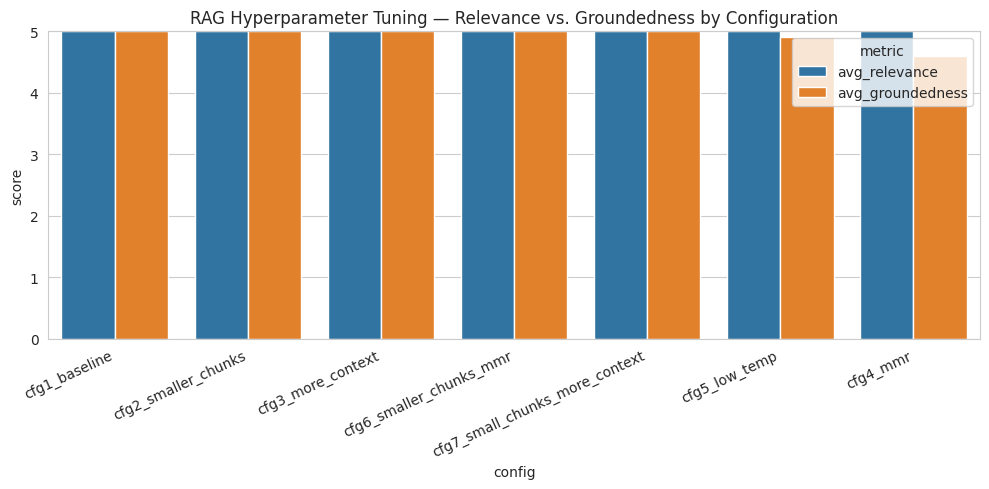

Configurations that outperformed the baseline: None
(Final configuration is chosen in the next cell, after the key-fact check.)


In [42]:
fig, ax = plt.subplots(figsize=(10,5))
tuning_summary_melted = tuning_summary.melt(
    id_vars="config", value_vars=["avg_relevance", "avg_groundedness"],
    var_name="metric", value_name="score"
)
sns.barplot(data=tuning_summary_melted, x="config", y="score", hue="metric", ax=ax)
plt.title("RAG Hyperparameter Tuning — Relevance vs. Groundedness by Configuration")
plt.xticks(rotation=25, ha="right")
plt.ylim(0, 5)
plt.tight_layout()
plt.show()

base = tuning_summary[tuning_summary["config"] == "cfg1_baseline"].iloc[0]
better = tuning_summary[
    (tuning_summary["avg_groundedness"] > base["avg_groundedness"]) |
    ((tuning_summary["avg_groundedness"] == base["avg_groundedness"]) &
     (tuning_summary["avg_relevance"] > base["avg_relevance"]))
]
print("Configurations that outperformed the baseline:", list(better["config"]) or "None")
print("(Final configuration is chosen in the next cell, after the key-fact check.)")

In [43]:
import re

key_facts = {   # from the Section 4 reference answers
    0: [r"encashment", r"transfer", r"bonus", r"seniority"],
    1: [r"\b(5|five)\s+consecutive", r"6 hours|six hours", r"24 hours"],
    2: [r"15 calendar days|15 days", r"helpline", r"e-?mail|portal", r"drop"],
    3: [r"4,?000", r"alcohol", r"receipt"],
    4: [r"4 hours|four hours"],
    5: [r"7 working days", r"5 working days", r"relieving letter"],
    6: [r"7 working days", r"review board", r"final"],
    7: [r"\b(2|two)\s+consecutive", r"HR Manager", r"supervisor"],
    8: [r"written warning", r"suspension", r"mandatory|quarterly"],
    9: [r"15 calendar days|15 days"],
}

def fact_recall(answer, q_index):
    hits = [bool(re.search(p, answer, re.I | re.S)) for p in key_facts[q_index]]
    return sum(hits) / len(hits)

tuning_df["key_fact_recall"] = [fact_recall(a, tuning_questions.index(q))
                                for a, q in zip(tuning_df["answer"], tuning_df["question"])]
rag_df["key_fact_recall"] = [fact_recall(a, i) for i, a in enumerate(rag_df["answer"])]

# Safe to re-run: drop the column first so a second run doesn't create _x / _y copies
kf = tuning_df.groupby("config")["key_fact_recall"].mean().rename("avg_key_fact_recall")
tuning_summary = (tuning_summary
                  .drop(columns="avg_key_fact_recall", errors="ignore")
                  .merge(kf, on="config"))

# Recall on the original 5 questions only, so it is comparable with the Section 8 baseline
tuning_df["q_idx"] = [tuning_questions.index(x) for x in tuning_df["question"]]
orig5 = (tuning_df[tuning_df["q_idx"] < 5].groupby("config")["key_fact_recall"]
         .mean().rename("key_fact_recall_orig5"))
tuning_summary = (tuning_summary
                  .drop(columns="key_fact_recall_orig5", errors="ignore")
                  .merge(orig5, on="config"))

print("Baseline RAG (Section 8, original 5 questions) avg key-fact recall:",
      round(rag_df["key_fact_recall"].mean(), 2))
display(tuning_summary.sort_values("avg_key_fact_recall", ascending=False))

# per-question view
tuning_df["q"] = ["Q" + str(i + 1) for i in tuning_df["q_idx"]]
pivot = tuning_df.pivot_table(index="config", columns="q", values="key_fact_recall")
display(pivot[sorted(pivot.columns, key=lambda c: int(c[1:]))])

best_config = tuning_summary.sort_values(
    ["avg_groundedness", "avg_relevance", "avg_key_fact_recall"], ascending=False
).iloc[0]["config"]
print("Configuration carried forward (judge scores first, key-fact recall as tie-break):", best_config)

Baseline RAG (Section 8, original 5 questions) avg key-fact recall: 0.77


,config,avg_relevance,avg_groundedness,n_chunks,avg_overall,avg_key_fact_recall,key_fact_recall_orig5
0,cfg1_baseline,5.0,5.0,21,5.00,0.908333,0.883333
5,cfg5_low_temp,5.0,4.9,21,4.95,0.850000,0.766667
2,cfg3_more_context,5.0,5.0,21,5.00,0.841667,0.816667
4,cfg7_small_chunks_more_context,5.0,5.0,25,5.00,0.808333,0.816667
3,cfg6_smaller_chunks_mmr,5.0,5.0,25,5.00,0.808333,0.683333
1,cfg2_smaller_chunks,5.0,5.0,25,5.00,0.775000,0.683333
6,cfg4_mmr,5.0,4.6,21,4.80,0.641667,0.550000


q,Q1,Q2,Q3,Q4,Q5,Q6,Q7,Q8,Q9,Q10
config,,,,,,,,,,
cfg1_baseline,1.00,0.666667,0.75,1.000000,1.0,0.666667,1.0,1.000000,1.000000,1.0
cfg2_smaller_chunks,1.00,0.000000,0.75,0.666667,1.0,0.666667,1.0,0.666667,1.000000,1.0
cfg3_more_context,1.00,0.333333,0.75,1.000000,1.0,0.666667,1.0,0.666667,1.000000,1.0
cfg4_mmr,0.00,0.333333,0.75,0.666667,1.0,0.666667,1.0,0.000000,1.000000,1.0
cfg5_low_temp,0.75,0.666667,0.75,0.666667,1.0,0.666667,1.0,1.000000,1.000000,1.0
cfg6_smaller_chunks_mmr,1.00,0.000000,0.75,0.666667,1.0,0.666667,1.0,1.000000,1.000000,1.0
cfg7_small_chunks_more_context,0.75,0.333333,1.00,1.000000,1.0,0.666667,1.0,1.000000,0.333333,1.0


Configuration carried forward (judge scores first, key-fact recall as tie-break): cfg1_baseline


In [44]:
q_checks = {
    "Q1": (eval_questions[0], r"encashment.{0,80}(transfer|bonus)"),
    "Q2": (eval_questions[1], r"up to 5 consecutive|5 consecutive working|five consecutive"),
}
probes = [("1000/150, k=3", 1000, 150, 3), ("1000/150, k=5", 1000, 150, 5), ("800/100, k=3", 800, 100, 3)]

for label, size, ovl, k in probes:
    sp = RecursiveCharacterTextSplitter(chunk_size=size, chunk_overlap=ovl,
                                        separators=["\n\n", "\n", ". ", " ", ""])
    cs = sp.split_documents(raw_docs)
    vs = Chroma.from_documents(documents=cs, embedding=embedding_model,
                               collection_name=f"probe_{uuid.uuid4().hex[:8]}")
    r = vs.as_retriever(search_type="similarity", search_kwargs={"k": k})
    for qname, (q, pat) in q_checks.items():
        in_store = any(re.search(pat, c.page_content, re.I) for c in cs)
        ctx = " ".join(d.page_content for d in r.invoke(q))
        print(f"{label} | {qname}: fact exists in a chunk={in_store} | reaches the model={bool(re.search(pat, ctx, re.I))}")

# Which fact do Q3 and Q4 keep missing?
def missing_facts(answer, q_index):
    return [p for p in key_facts[q_index] if not re.search(p, answer, re.I | re.S)]

for qi in (2, 3):
    for cfg in ["cfg1_baseline", "cfg2_smaller_chunks"]:
        a = tuning_df[(tuning_df["config"] == cfg) & (tuning_df["q_idx"] == qi)]["answer"].iloc[0]
        print(f"Q{qi+1} {cfg} missing:", missing_facts(a, qi))

1000/150, k=3 | Q1: fact exists in a chunk=True | reaches the model=True
1000/150, k=3 | Q2: fact exists in a chunk=True | reaches the model=True
1000/150, k=5 | Q1: fact exists in a chunk=True | reaches the model=True
1000/150, k=5 | Q2: fact exists in a chunk=True | reaches the model=True
800/100, k=3 | Q1: fact exists in a chunk=True | reaches the model=True
800/100, k=3 | Q2: fact exists in a chunk=True | reaches the model=False
Q3 cfg1_baseline missing: ['15 calendar days|15 days']
Q3 cfg2_smaller_chunks missing: ['15 calendar days|15 days']
Q4 cfg1_baseline missing: []
Q4 cfg2_smaller_chunks missing: ['receipt']


**Key-fact check:** The judge gave 5.0 relevance to every configuration and 5.0 groundedness to five of seven, so it cannot rank them. As a second signal, each answer was checked for the key facts in the Section 4 reference answers, for example "5 consecutive" for Q2 or "4,000" for Q4. This is a keyword proxy and can miss a correct answer worded differently.

* **cfg1_baseline has the highest key-fact recall:** 0.91 over 10 questions and 0.88 on the original 5. The next best are cfg5_low_temp (0.85) and cfg3_more_context (0.84).
* **The same configuration scored differently between runs.** cfg1 is identical to the Section 8 setup, yet its recall on the original 5 rose from 0.77 to 0.88 because Q1 (seniority) and Q4 (receipts) were included this time. At temperature 0.3, run-to-run variation is about 0.1. Gaps smaller than that should not be treated as real.
* **Smaller chunks lose the Q2 entitlement.** cfg2 and cfg6 (800/100, k=3) score 0.0 on Q2. The probe confirms that the 5-day line exists in an 800-character chunk but does not reach the model at k=3. With k=5 (cfg7) it partly recovers (0.33).
* **Q2 is never complete.** The best result is 0.67 (cfg1, cfg5). In the Section 8 answer the missing fact is the 24-hour written notice, which sits on a separate page from the 6-hour rule (Section 7.5).
* **Q3 scores 0.75 in every configuration except cfg7 (800/100, k=5), which reaches 1.0.** In cfg1 and cfg2 the missing fact is the 15-day window. cfg7, however, drops to 0.33 on Q9.
* **MMR with large chunks fails outright on probation questions.** cfg4 scores 0.0 on both Q1 and Q8.

**Observations - RAG Hyperparameter Tuning**

| Config | Settings | Avg Relevance | Avg Groundedness | Key-fact recall (10 Q) | Key-fact recall (original 5) |
|---|---|---|---|---|---|
| cfg1_baseline | 1000/150, k=3, similarity, temp 0.3 | 5.0 | 5.0 | 0.91 | 0.88 |
| cfg5_low_temp | 1000/150, k=3, similarity, temp 0.0 | 5.0 | 4.9 | 0.85 | 0.77 |
| cfg3_more_context | 1000/150, k=5, similarity, temp 0.3 | 5.0 | 5.0 | 0.84 | 0.82 |
| cfg7_small_chunks_more_context | 800/100, k=5, similarity, temp 0.3 | 5.0 | 5.0 | 0.81 | 0.82 |
| cfg6_smaller_chunks_mmr | 800/100, k=3, MMR, temp 0.3 | 5.0 | 5.0 | 0.81 | 0.68 |
| cfg2_smaller_chunks | 800/100, k=3, similarity, temp 0.3 | 5.0 | 5.0 | 0.78 | 0.68 |
| cfg4_mmr | 1000/150, k=3, MMR, temp 0.3 | 5.0 | 4.6 | 0.64 | 0.55 |

* **No configuration beat the baseline.** The judge found no improvement over cfg1, and cfg1 also has the highest key-fact recall. Tuning confirms the Section 7 choice rather than replacing it.
* **Chunk size is the strongest lever.** At k=3, moving from 1000/150 to 800/100 cut recall from 0.91 to 0.78, mainly because the Q2 entitlement no longer reached the model.
* **More context (k=5) did not help.** cfg3 matches cfg1 on the judge but scores lower on recall (0.84), with Q2 down to 0.33. The extra chunks added noise rather than missing facts.
* **MMR did not fix the off-topic chunks, and with large chunks it caused the worst result** (groundedness 4.6, recall 0.64, Q1 and Q8 both 0.0). The likely reason: with only 21 chunks, pushing for diversity swaps a second relevant probation chunk for an unrelated one. MMR with smaller chunks (cfg6) avoided the probation failure but still lost Q2.
* **Temperature 0 (cfg5)** gives repeatable answers with groundedness 4.9 and recall 0.85. The gap to cfg1 (0.06) is within the run-to-run variation seen for cfg1 itself.
* **The judge saturates.** It gave 5.0 relevance to all seven configurations and could not separate them. Fact-level checks were needed to see the real differences.

**Key takeaway:** cfg1_baseline (1000/150, k=3, similarity) is carried forward. cfg4 (MMR with large chunks) and the 800/100 k=3 settings are not recommended. Changing k or search type did not close the remaining gaps (Q2's notice periods, Q3's 15-day window). Section 9.1 tests a chunking change directly.

## 9.1 Additional Experiment: Page-Merged Chunking (cfg8)

Section 7.5 found that chunks never cross page breaks, because the PDF is split page by page. This cuts the bereavement notification rule in two: the 6-hour verbal notice is on page 8 and the 24-hour written notice is on page 9. cfg8 joins all cleaned pages into one document before splitting. Every other setting is identical to cfg1 (1000/150, k=3, similarity, temperature 0.3), so the chunking change is the only setting that differs.

In [51]:
# Join all cleaned pages into one document, then split with the cfg1 settings
from langchain_core.documents import Document

merged_doc = Document(
    page_content=" ".join(d.page_content for d in raw_docs),
    metadata={"source": pdf_path},
)
merged_splitter = RecursiveCharacterTextSplitter(
    chunk_size=1000, chunk_overlap=150,
    separators=["\n\n", "\n", ". ", " ", ""],
)
merged_chunks = merged_splitter.split_documents([merged_doc])
merged_store = Chroma.from_documents(
    documents=merged_chunks, embedding=embedding_model,
    collection_name=f"flykite_merged_{uuid.uuid4().hex[:10]}",
)
assert merged_store._collection.count() == len(merged_chunks)
merged_retriever = merged_store.as_retriever(search_type="similarity", search_kwargs={"k": 3})
print("cfg8 chunks:", len(merged_chunks))

# Does the bereavement notification rule now sit in one chunk, and does it reach the model for Q2?
pat_6h = r"Verbal noti.{1,2}cation within 6 hours"
pat_24h = r"Written/email noti.{1,2}cation within 24 hours"
same_chunk = any(re.search(pat_6h, c.page_content) and re.search(pat_24h, c.page_content)
                 for c in merged_chunks)
q2_ctx = " ".join(d.page_content for d in merged_retriever.invoke(eval_questions[1]))
print("6-hour and 24-hour rules in the same chunk:", same_chunk)
print("24-hour rule reaches the model for Q2:", bool(re.search(pat_24h, q2_ctx)))

cfg8 chunks: 16
6-hour and 24-hour rules in the same chunk: True
24-hour rule reaches the model for Q2: False


In [52]:
cfg8_records = []
for q in tuning_questions:
    answer, context, docs = rag_answer(q, merged_retriever, temperature=0.3)
    score = judge_response(q, answer, context=context)
    cfg8_records.append({
        "question": q, "answer": answer,
        "relevance": score.get("relevance"), "groundedness": score.get("groundedness"),
        "key_fact_recall": fact_recall(answer, tuning_questions.index(q)),
    })
cfg8_df = pd.DataFrame(cfg8_records)
cfg8_df["q"] = ["Q" + str(i + 1) for i in range(len(cfg8_df))]

cfg1_df = tuning_df[tuning_df["config"] == "cfg1_baseline"]
comparison_cfg8 = pd.DataFrame({
    "Metric": ["Avg Relevance", "Avg Groundedness", "Key-fact recall (10 Q)", "Key-fact recall (original 5)"],
    "cfg1_baseline": [cfg1_df["relevance"].mean(), cfg1_df["groundedness"].mean(),
                      cfg1_df["key_fact_recall"].mean(),
                      cfg1_df[cfg1_df["q_idx"] < 5]["key_fact_recall"].mean()],
    "cfg8_merged_pages": [cfg8_df["relevance"].mean(), cfg8_df["groundedness"].mean(),
                          cfg8_df["key_fact_recall"].mean(),
                          cfg8_df.iloc[:5]["key_fact_recall"].mean()],
}).round(2)
display(comparison_cfg8)

per_q = pd.DataFrame({
    "cfg1_baseline": pivot.loc["cfg1_baseline"],
    "cfg8_merged_pages": cfg8_df.set_index("q")["key_fact_recall"],
})
per_q = per_q.loc[sorted(per_q.index, key=lambda c: int(c[1:]))].round(2)
display(per_q.T)

,Metric,cfg1_baseline,cfg8_merged_pages
0,Avg Relevance,5.00,4.80
1,Avg Groundedness,5.00,4.90
2,Key-fact recall (10 Q),0.91,0.71
3,Key-fact recall (original 5),0.88,0.55


q,Q1,Q2,Q3,Q4,Q5,Q6,Q7,Q8,Q9,Q10
cfg1_baseline,1.00,0.67,0.75,1.00,1.0,0.67,1.0,1.00,1.0,1.0
cfg8_merged_pages,0.75,0.33,1.00,0.67,0.0,0.67,1.0,0.67,1.0,1.0


In [53]:
for qi in (1, 2):
    row = cfg8_df.iloc[qi]
    print(f"Q{qi+1}: {row['question']}\n\nA: {row['answer']}\n")
    print("Missing key facts:", missing_facts(row["answer"], qi))
    print("-" * 100)

Q2: There has been a demise in my family last night, and I need to attend the last rites. How should I inform the office, and will I be granted leave?

A: Based on the policy context provided, you should submit the death certificate, funeral notice, or obituary as documentation for bereavement leave. You need to provide this documentation within 5 working days of returning to duty.

For your leave request, you are entitled to up to 5 consecutive working days of bereavement leave. Since this is a natural disaster situation, it falls under the natural disaster policy as well, which allows a maximum of 7 consecutive calendar days per incident. However, any additional days beyond the initial 5 working days would require conversion from annual leave or unpaid leave.

Therefore, you should inform your supervisor and HR about the situation and submit the required documentation as soon as possible to ensure the leave is granted.

Missing key facts: ['6 hours|six hours', '24 hours']
-----------

**Observations - Page-Merged Chunking (cfg8)**

| Metric | cfg1_baseline | cfg8_merged_pages |
|---|---|---|
| Avg Relevance | 5.0 | 4.8 |
| Avg Groundedness | 5.0 | 4.9 |
| Key-fact recall (10 Q) | 0.91 | 0.71 |
| Key-fact recall (original 5) | 0.88 | 0.55 |

* **The split was fixed, but the rule still did not reach the model.** After merging, the 6-hour and 24-hour notification rules sit in the same chunk (16 chunks instead of 21). That chunk was not in the top 3 for Q2, so the answer has neither notice period. Q2's gap is a retrieval-ranking problem, not only a chunk-boundary one.
* **Merging introduced a misapplied rule.** Without page breaks, chunks run across the end of one policy and the start of the next. Q2's answer pulled in the natural-disaster leave rule and called a family death "a natural disaster situation".
* **One gain:** Q3 rose to 1.0 and now states the 15-day reporting window, matching cfg7.
* **Losses elsewhere:** Q5 fell from 1.0 to 0.0 (the 4-hour window was not stated). Q1 fell to 0.75, Q4 to 0.67 and Q8 to 0.67.
* The recall drop (0.91 to 0.71) is twice the run-to-run variation of about 0.1 seen for cfg1, so it is unlikely to be noise, although it comes from a single run.

**Key takeaway:** Merging pages is not the fix. It keeps the notification rule together but blurs policy boundaries, which likely weakens retrieval and invites misapplied rules. cfg1 stays the selected configuration. A better next test is section-aware splitting: split on the handbook's numbered headings so each chunk holds one complete policy, regardless of page.

# 10. Actionable Insights and Recommendations

This section compares every method built across the full project — base LLM, prompt-engineered LLM, baseline RAG, and tuned RAG — and translates the technical results into business guidance for Flykite.

In [48]:
tuned_row = tuning_summary[tuning_summary["config"] == best_config].iloc[0]
base_row = tuning_summary[tuning_summary["config"] == "cfg1_baseline"].iloc[0]

runner_up = (tuning_summary[tuning_summary["config"] != best_config]
             .sort_values(["avg_groundedness", "avg_relevance", "avg_key_fact_recall"], ascending=False)
             .iloc[0])
tuned_finding = (
    f"Best of 7 configs (10 questions): judge {tuned_row['avg_relevance']:.1f}/{tuned_row['avg_groundedness']:.1f}, "
    f"key-fact recall {tuned_row['avg_key_fact_recall']:.2f} vs {runner_up['avg_key_fact_recall']:.2f} "
    f"for next best ({runner_up['config']})"
)

issues = manual.loc[manual["manual_relevance"] < 5, "comment"].tolist()
manual_finding = "; ".join(issues) if issues else "No gaps found on manual check"

final_comparison = pd.DataFrame({
    "Method": [
        "Base LLM (no prompt)",
        "Prompt-Engineered LLM (P2 v3)",
        "RAG (baseline) - automated",
        "RAG (baseline) - manual-adjusted",
        f"RAG tuned ({best_config})",
    ],
    "Avg Relevance": [
        baseline_df["relevance"].mean(),
        prompt_dfs["P2: Few-Shot Exemplar"]["relevance"].mean(),
        rag_df["relevance"].mean(),
        manual["manual_relevance"].mean(),
        tuned_row["avg_relevance"],
    ],
    "Avg Groundedness": [
        baseline_df["groundedness"].mean(),
        prompt_dfs["P2: Few-Shot Exemplar"]["groundedness"].mean(),
        rag_df["groundedness"].mean(),
        manual["manual_groundedness"].mean(),
        tuned_row["avg_groundedness"],
    ],
    "Key Finding": [
        "Fluent, but not tied to Flykite's policy",
        "Small gain; cannot supply policy facts it never saw",
        "Strong grounding on the automated judge",
        manual_finding,
        tuned_finding,
    ],
})
final_comparison

,Method,Avg Relevance,Avg Groundedness,Key Finding
0,Base LLM (no prompt),4.2,3.2,"Fluent, but not tied to Flykite's policy"
1,Prompt-Engineered LLM (P2 v3),4.2,3.4,Small gain; cannot supply policy facts it never saw
2,RAG (baseline) - automated,5.0,5.0,Strong grounding on the automated judge
3,RAG (baseline) - manual-adjusted,4.4,4.8,"Q1: omits that seniority accrual starts only after probation; Q2: applies 48-hour planned-leave rule to an emergency, adds peak-operations condition, omits 24-hour written notice; Q3: omits the 15-calendar-day reporting window"
4,RAG tuned (cfg1_baseline),5.0,5.0,"Best of 7 configs (10 questions): judge 5.0/5.0, key-fact recall 0.91 vs 0.84 for next best (cfg3_more_context)"


*Automated rows are judge scores. The manual-adjusted row is my own check of the five Section 8 RAG answers against the Section 4 reference answers (Q1, Q2 and Q3 lowered on relevance, Q2 lowered on groundedness). The base LLM, prompt-engineered and RAG baseline rows use the 5 evaluation questions; the tuned row uses all 10 tuning questions.*

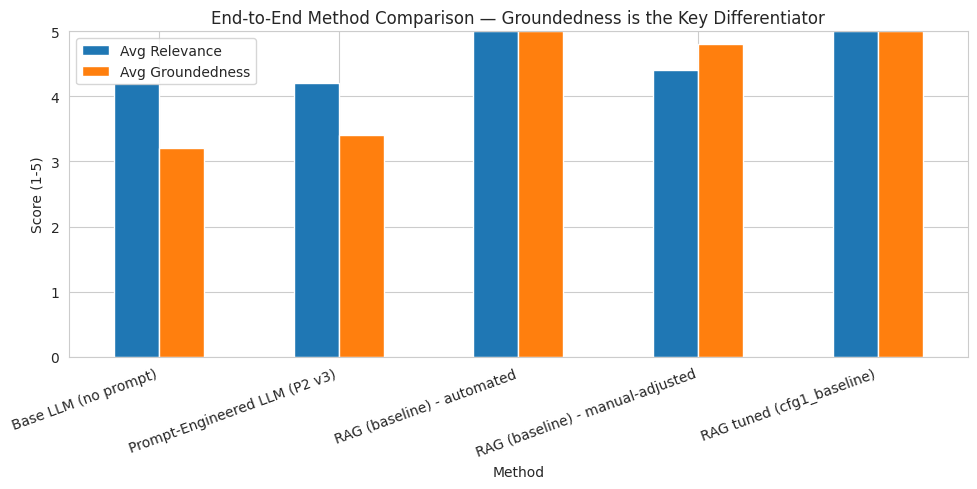

In [49]:
fig, ax = plt.subplots(figsize=(10,5))
final_comparison.set_index("Method")[["Avg Relevance", "Avg Groundedness"]].plot(kind="bar", ax=ax)
plt.title("End-to-End Method Comparison — Groundedness is the Key Differentiator")
plt.ylabel("Score (1-5)")
plt.xticks(rotation=20, ha="right")
plt.ylim(0, 5)
plt.tight_layout()
plt.show()

## Key Insights

1. **Groundedness, not relevance, separates the methods.** Relevance stays between 4.2 and 5.0 for every approach. Groundedness rises from 3.2 for the base LLM, to 2.8-3.6 with prompt engineering, to 5.0 with RAG (4.8 after manual review).
2. **Prompting cannot supply facts.** No prompt-only answer contained a single Flykite figure. Self-critique prompting even made things worse, by presenting generic figures as Flykite practice.
3. **RAG turns generic advice into policy answers employees can act on:** the ₹4,000 per diem, the 4-hour hazard window, the HR Helpline number, the 5-day bereavement entitlement. Its remaining errors are omissions and misapplied rules, not invented facts.
4. **Tuning confirmed the baseline.** None of the changes that looked promising helped. Smaller chunks, more context (k=5), MMR and merging pages all lowered answer completeness, and MMR with large chunks failed two probation questions entirely.
5. **Chunk structure is the main remaining risk.** Page-by-page splitting cuts rules that run across a page break, such as the bereavement notification rule. Merging pages (cfg8) kept that rule in one chunk but still did not get it to the model for Q2, and lowered key-fact recall from 0.91 to 0.71 by mixing neighbouring policies. Chunks need to follow the handbook's own section structure.
6. **The automated judge is not enough on its own.** It scored almost every RAG answer 5/5 and missed omitted deadlines. Fact-level checks and manual review found the real gaps.

## Business Recommendations

1. **Pilot the RAG system with the cfg1 settings** (chunk size 1000, overlap 150, k=3, similarity search). If HR needs identical answers to identical questions, run generation at temperature 0 (cfg5). In this test that cost 0.06 recall, which is within normal run-to-run variation.
2. **Split on section headings before rollout.** Page-by-page splitting cuts multi-part rules, and merging pages (tested as cfg8) made results worse. Splitting on the handbook's numbered section headings should keep each rule whole without mixing policies. Re-test Q2, Q3 and Q5 after the change.
3. **Require complete, cited answers.** Add a system-prompt rule to list every deadline and notification step found in the context, and to name the policy section each one comes from. Showing the source section to the employee supports the trust and compliance goal.
4. **Keep a human path for sensitive cases.** For harassment, bereavement and safety questions, always show the HR Helpline or supervisor contact alongside the answer, so the bot supports HR rather than replacing it.
5. **Expand the evaluation before wider use.** Build a gold set of 30-50 questions with their key facts, covering every policy area. Track fact recall alongside judge scores, and use a different model as judge.
6. **Re-index whenever the handbook changes**, so answers never cite a superseded policy.

# 11. Conclusion

This project compared four ways of answering Flykite HR policy questions: a base LLM, a prompt-engineered LLM, RAG, and RAG with hyperparameter tuning.

* **Base LLM:** gave fluent, generic answers with no Flykite facts. Groundedness 3.2/5.
* **Prompt engineering:** reduced invented figures but could not add policy facts. Groundedness 2.8-3.6/5; P2 v3, the prompt carried forward, scored 3.4/5.
* **RAG:** gave Flykite's actual entitlements, contacts and deadlines. It scored 5.0/5 on both metrics from the automated judge, and 4.4/5 relevance and 4.8/5 groundedness after manual review. The remaining errors are omissions and one misapplied rule: seniority (Q1), the 24-hour written notice and the 48-hour planned-leave rule (Q2), and the 15-day reporting window (Q3).
* **Tuning:** seven configurations were tested and none beat the baseline. cfg1 (1000/150, k=3, similarity) had the highest key-fact recall (0.91). MMR with large chunks performed worst (0.64). A follow-up test that merged pages before splitting (cfg8) kept the bereavement notification rule in one chunk but lowered recall to 0.71, so cfg1 remains the selected configuration.

## Future Scope

This prototype answers questions from one handbook in English. A version Flykite could use day to day would go further:

* **Hybrid search and re-ranking.** Pair the embedding search with keyword search (BM25) and add a re-ranker. Exact terms like "bereavement" or "per diem" would then reliably pull the right clause, which is where the current retriever slipped on Q2.
* **More documents, kept current.** Add the full set of HR documents (benefits guides, union agreements, regional policies) and track which version each answer came from, so employees never get an outdated rule.
* **Role-aware answers.** Pilots, cabin crew and ground staff work under different rules. Tagging chunks by role and location would let the bot answer for the employee's own situation instead of giving a general answer.
* **Follow-up questions.** Employees rarely ask one perfect question. Keeping the conversation context would let someone ask "and what if I'm still on probation?" without starting over.
* **Where employees already work.** Deploying through Microsoft Teams, Slack or the HR portal would make it part of the normal workflow rather than another tool to open.
* **Hand-off to HR.** For sensitive cases like harassment or a death in the family, the bot could open an HR ticket or connect the employee to a person, with the conversation attached.
* **Learning from use.** A simple thumbs up or down on each answer, plus tracking which questions come up most, would show HR where the bot falls short and which policies employees find confusing. That second point is useful even outside the bot.
* **Multilingual support.** Flykite's workforce likely spans several languages. Answering in Hindi or other regional languages from the same English handbook would widen who can use it.